In [2]:
# ═══════════════════════════════════════════════════════════════
# Cell 1: Import Libraries
# ═══════════════════════════════════════════════════════════════

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

import pandas as pd
import numpy as np
import re
import string
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import ssl
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data
# Method 1: Disable SSL verification (temporary fix)
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

# Now download
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)


print("✓ All libraries imported successfully!")


✓ All libraries imported successfully!


In [29]:
# ═══════════════════════════════════════════════════════════════
# Cell 2: Configuration & Setup
# ═══════════════════════════════════════════════════════════════

# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

class Config:
    """Project Configuration"""
    
    # Data paths
    DATA_PATH = 'dataset/Combined Data.csv'
    
    # Data processing
    MAX_VOCAB_SIZE = 20000
    MAX_SEQ_LENGTH = 100
    MIN_WORD_FREQ = 2
    
    # Model parameters
    EMBEDDING_DIM = 300
    HIDDEN_DIM = 256
    NUM_LAYERS = 2
    DROPOUT = 0.5
    BIDIRECTIONAL = True
    
    # Training parameters
    BATCH_SIZE = 32
    LEARNING_RATE = 0.001
    NUM_EPOCHS = 10
    PATIENCE = 7  # Early stopping patience
    GRADIENT_CLIP = 1.0
    
    # Data split
    TRAIN_SIZE = 0.7
    VAL_SIZE = 0.15
    TEST_SIZE = 0.15
    
    # Device
    DEVICE = device

config = Config()

print("\n" + "="*60)
print("PROJECT CONFIGURATION")
print("="*60)
print(f"Dataset Path: {config.DATA_PATH}")
print(f"Max Vocab Size: {config.MAX_VOCAB_SIZE}")
print(f"Max Sequence Length: {config.MAX_SEQ_LENGTH}")
print(f"Embedding Dim: {config.EMBEDDING_DIM}")
print(f"Hidden Dim: {config.HIDDEN_DIM}")
print(f"Num Layers: {config.NUM_LAYERS}")
print(f"Dropout: {config.DROPOUT}")
print(f"Batch Size: {config.BATCH_SIZE}")
print(f"Learning Rate: {config.LEARNING_RATE}")
print(f"Max Epochs: {config.NUM_EPOCHS}")
print(f"Early Stopping Patience: {config.PATIENCE}")
print("="*60)


Using device: cpu

PROJECT CONFIGURATION
Dataset Path: dataset/Combined Data.csv
Max Vocab Size: 20000
Max Sequence Length: 100
Embedding Dim: 300
Hidden Dim: 256
Num Layers: 2
Dropout: 0.5
Batch Size: 32
Learning Rate: 0.001
Max Epochs: 10
Early Stopping Patience: 7


Dataset loaded successfully!
Shape: (53043, 3)

Columns: ['Unnamed: 0', 'statement', 'status']

First few rows:
   Unnamed: 0                                          statement   status
0           0                                         oh my gosh  Anxiety
1           1  trouble sleeping, confused mind, restless hear...  Anxiety
2           2  All wrong, back off dear, forward doubt. Stay ...  Anxiety
3           3  I've shifted my focus to something else but I'...  Anxiety
4           4  I'm restless and restless, it's been a month n...  Anxiety

DATASET STATISTICS
Total samples: 53043
Missing values in 'statement': 362
Missing values in 'status': 0

Class distribution:
status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64

Number of classes: 7


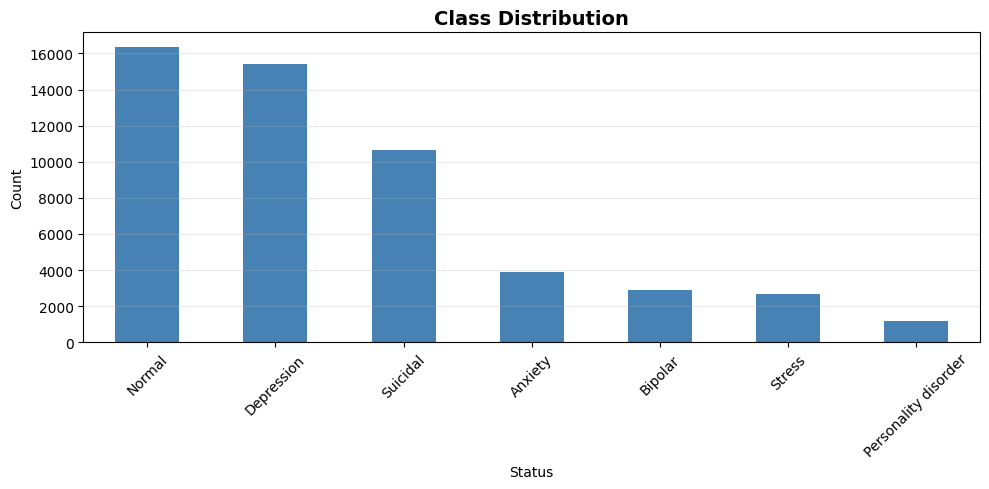


After removing missing values: 52681 samples


In [30]:
# ═══════════════════════════════════════════════════════════════
# Cell 3: Load Dataset
# ═══════════════════════════════════════════════════════════════

# Load data
df = pd.read_csv(config.DATA_PATH)

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
print(df.head())

# Check for required columns
assert 'statement' in df.columns, "Column 'statement' not found!"
assert 'status' in df.columns, "Column 'status' not found!"

# Basic statistics
print(f"\n{'='*60}")
print("DATASET STATISTICS")
print(f"{'='*60}")
print(f"Total samples: {len(df)}")
print(f"Missing values in 'statement': {df['statement'].isna().sum()}")
print(f"Missing values in 'status': {df['status'].isna().sum()}")

# Class distribution
print(f"\nClass distribution:")
class_counts = df['status'].value_counts()
print(class_counts)
print(f"\nNumber of classes: {df['status'].nunique()}")

# Visualize class distribution
plt.figure(figsize=(10, 5))
class_counts.plot(kind='bar', color='steelblue')
plt.title('Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Remove missing values
df = df.dropna(subset=['statement', 'status'])
print(f"\nAfter removing missing values: {len(df)} samples")


In [31]:
# ═══════════════════════════════════════════════════════════════
# Cell 4: Text Preprocessing
# ═══════════════════════════════════════════════════════════════

class TextPreprocessor:
    """Advanced text preprocessing for NLP"""
    
    def __init__(self, remove_stopwords=True, lowercase=True):
        self.remove_stopwords = remove_stopwords
        self.lowercase = lowercase
        self.stop_words = set(stopwords.words('english')) if remove_stopwords else set()
        
    def clean_text(self, text):
        """Clean and normalize text"""
        if not isinstance(text, str):
            return ""
        
        # Lowercase
        if self.lowercase:
            text = text.lower()
        
        # Remove URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        
        # Remove email addresses
        text = re.sub(r'\S+@\S+', '', text)
        
        # Remove mentions and hashtags
        text = re.sub(r'@\w+|#\w+', '', text)
        
        # Remove numbers (optional - comment out if you need numbers)
        # text = re.sub(r'\d+', '', text)
        
        # Remove punctuation
        text = text.translate(str.maketrans('', '', string.punctuation))
        
        # Remove extra whitespace
        text = re.sub(r'\s+', ' ', text).strip()
        
        return text
    
    def tokenize(self, text):
        """Tokenize text"""
        try:
            tokens = word_tokenize(text)
        except:
            tokens = text.split()
        
        # Remove stopwords
        if self.remove_stopwords:
            tokens = [t for t in tokens if t not in self.stop_words]
        
        # Remove very short tokens
        tokens = [t for t in tokens if len(t) > 1]
        
        return tokens
    
    def preprocess(self, text):
        """Full preprocessing pipeline"""
        text = self.clean_text(text)
        tokens = self.tokenize(text)
        return tokens

# Initialize preprocessor
preprocessor = TextPreprocessor(remove_stopwords=True, lowercase=True)

# Test preprocessing
sample_text = df['statement'].iloc[0]
print("Original text:")
print(sample_text)
print("\nPreprocessed tokens:")
print(preprocessor.preprocess(sample_text))


Original text:
oh my gosh

Preprocessed tokens:
['oh', 'gosh']


Preprocessing all texts...


100%|██████████| 52681/52681 [00:08<00:00, 6350.98it/s] 

After removing empty sequences: 52534 samples

SEQUENCE LENGTH STATISTICS
Mean length: 51.29
Median length: 28.00
Min length: 1
Max length: 2520
Std deviation: 72.88


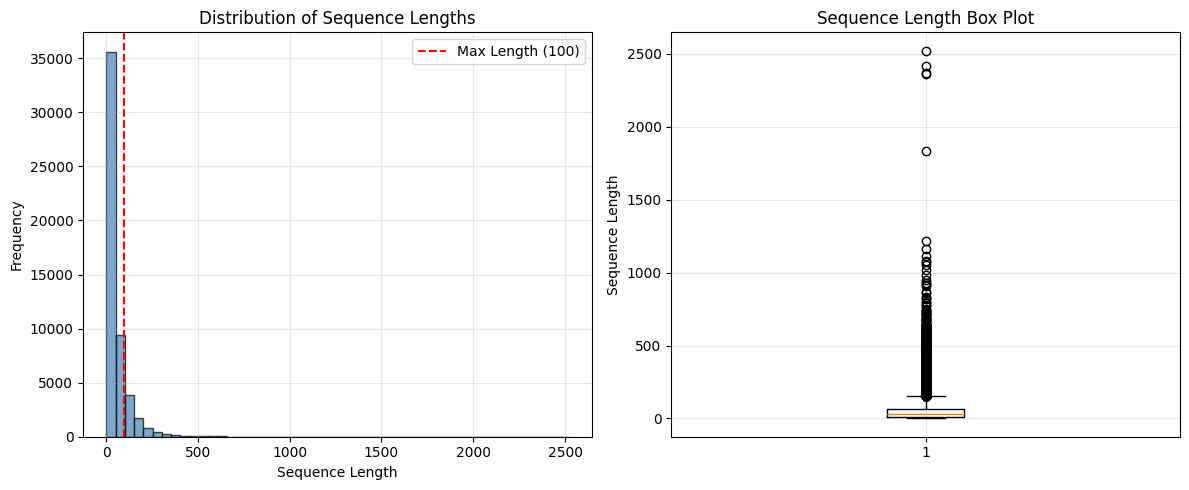


Percentage of sequences > 100: 14.56%


In [32]:
# ═══════════════════════════════════════════════════════════════
# Cell 5: Apply Preprocessing to Dataset
# ═══════════════════════════════════════════════════════════════

from tqdm.auto import tqdm
tqdm.pandas()

print("Preprocessing all texts...")
df['tokens'] = df['statement'].progress_apply(
    lambda x: preprocessor.preprocess(x)
)

# Remove empty sequences
df = df[df['tokens'].apply(len) > 0]
print(f"After removing empty sequences: {len(df)} samples")

# Statistics
seq_lengths = df['tokens'].apply(len)
print(f"\n{'='*60}")
print("SEQUENCE LENGTH STATISTICS")
print(f"{'='*60}")
print(f"Mean length: {seq_lengths.mean():.2f}")
print(f"Median length: {seq_lengths.median():.2f}")
print(f"Min length: {seq_lengths.min()}")
print(f"Max length: {seq_lengths.max()}")
print(f"Std deviation: {seq_lengths.std():.2f}")

# Visualize sequence length distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(seq_lengths, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(config.MAX_SEQ_LENGTH, color='red', linestyle='--', 
            label=f'Max Length ({config.MAX_SEQ_LENGTH})')
plt.xlabel('Sequence Length')
plt.ylabel('Frequency')
plt.title('Distribution of Sequence Lengths')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot(seq_lengths, vert=True)
plt.ylabel('Sequence Length')
plt.title('Sequence Length Box Plot')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Show percentage of sequences that will be truncated
truncated_pct = (seq_lengths > config.MAX_SEQ_LENGTH).sum() / len(seq_lengths) * 100
print(f"\nPercentage of sequences > {config.MAX_SEQ_LENGTH}: {truncated_pct:.2f}%")


In [33]:
# ═══════════════════════════════════════════════════════════════
# Cell 6: Build Vocabulary
# ═══════════════════════════════════════════════════════════════

class Vocabulary:
    """Vocabulary builder for text data"""
    
    def __init__(self, max_size=None, min_freq=1):
        self.max_size = max_size
        self.min_freq = min_freq
        self.word2idx = {'<PAD>': 0, '<UNK>': 1}
        self.idx2word = {0: '<PAD>', 1: '<UNK>'}
        self.word_freq = Counter()
        
    def build_vocab(self, tokenized_texts):
        """Build vocabulary from tokenized texts"""
        print("Building vocabulary...")
        
        # Count word frequencies
        for tokens in tokenized_texts:
            self.word_freq.update(tokens)
        
        print(f"Total unique words before filtering: {len(self.word_freq)}")
        
        # Filter by minimum frequency
        filtered_words = [
            word for word, freq in self.word_freq.items() 
            if freq >= self.min_freq
        ]
        print(f"Words after min_freq={self.min_freq} filtering: {len(filtered_words)}")
        
        # Sort by frequency and limit vocabulary size
        sorted_words = sorted(
            filtered_words, 
            key=lambda x: self.word_freq[x], 
            reverse=True
        )
        
        if self.max_size:
            sorted_words = sorted_words[:self.max_size - 2]  # -2 for PAD and UNK
        
        # Build word2idx and idx2word
        for idx, word in enumerate(sorted_words, start=2):
            self.word2idx[word] = idx
            self.idx2word[idx] = word
        
        print(f"Final vocabulary size: {len(self.word2idx)}")
        
    def encode(self, tokens, max_length=None):
        """Convert tokens to indices"""
        indices = [self.word2idx.get(token, self.word2idx['<UNK>']) for token in tokens]
        
        if max_length:
            if len(indices) > max_length:
                indices = indices[:max_length]
            # Padding will be handled by DataLoader
        
        return indices
    
    def decode(self, indices):
        """Convert indices back to tokens"""
        return [self.idx2word.get(idx, '<UNK>') for idx in indices]
    
    def __len__(self):
        return len(self.word2idx)

# Build vocabulary
vocab = Vocabulary(max_size=config.MAX_VOCAB_SIZE, min_freq=config.MIN_WORD_FREQ)
vocab.build_vocab(df['tokens'].tolist())

print(f"\n{'='*60}")
print("VOCABULARY STATISTICS")
print(f"{'='*60}")
print(f"Vocabulary size: {len(vocab)}")
print(f"Most common words:")
for word, freq in vocab.word_freq.most_common(20):
    print(f"  {word}: {freq}")


Building vocabulary...
Total unique words before filtering: 77334
Words after min_freq=2 filtering: 32310
Final vocabulary size: 20000

VOCABULARY STATISTICS
Vocabulary size: 20000
Most common words:
  like: 38264
  feel: 31593
  want: 27291
  know: 23542
  life: 22168
  get: 21730
  even: 18711
  time: 17906
  would: 16820
  people: 16545
  really: 16371
  one: 14598
  going: 13849
  im: 13827
  think: 13032
  go: 12451
  much: 11844
  never: 11765
  day: 11702
  help: 10636


In [34]:
# ═══════════════════════════════════════════════════════════════
# Cell 7: Encode Texts and Labels
# ═══════════════════════════════════════════════════════════════

# Encode texts
print("Encoding texts...")
df['encoded'] = df['tokens'].apply(
    lambda x: vocab.encode(x, max_length=config.MAX_SEQ_LENGTH)
)

# Encode labels
print("Encoding labels...")
label2idx = {label: idx for idx, label in enumerate(sorted(df['status'].unique()))}
idx2label = {idx: label for label, idx in label2idx.items()}
df['label'] = df['status'].map(label2idx)

print(f"\n{'='*60}")
print("LABEL ENCODING")
print(f"{'='*60}")
print("Label mapping:")
for label, idx in label2idx.items():
    count = (df['label'] == idx).sum()
    print(f"  {label} -> {idx} (count: {count})")

num_classes = len(label2idx)
print(f"\nTotal number of classes: {num_classes}")

# Verify encoding
print(f"\nSample encoding:")
sample_idx = 0
print(f"Original: {df['statement'].iloc[sample_idx][:100]}...")
print(f"Tokens: {df['tokens'].iloc[sample_idx][:10]}...")
print(f"Encoded: {df['encoded'].iloc[sample_idx][:10]}...")
print(f"Label: {df['status'].iloc[sample_idx]} -> {df['label'].iloc[sample_idx]}")


Encoding texts...
Encoding labels...

LABEL ENCODING
Label mapping:
  Anxiety -> 0 (count: 3841)
  Bipolar -> 1 (count: 2777)
  Depression -> 2 (count: 15395)
  Normal -> 3 (count: 16211)
  Personality disorder -> 4 (count: 1077)
  Stress -> 5 (count: 2585)
  Suicidal -> 6 (count: 10648)

Total number of classes: 7

Sample encoding:
Original: oh my gosh...
Tokens: ['oh', 'gosh']...
Encoded: [477, 4603]...
Label: Anxiety -> 0


In [35]:
# ═══════════════════════════════════════════════════════════════
# Cell 8: Split Dataset
# ═══════════════════════════════════════════════════════════════

# Prepare data
X = df['encoded'].tolist()
y = df['label'].tolist()

# First split: train + val vs test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=config.TEST_SIZE, 
    random_state=SEED,
    stratify=y
)

# Second split: train vs val
val_size_adjusted = config.VAL_SIZE / (config.TRAIN_SIZE + config.VAL_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=val_size_adjusted,
    random_state=SEED,
    stratify=y_temp
)

print(f"{'='*60}")
print("DATASET SPLIT")
print(f"{'='*60}")
print(f"Train set: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Val set:   {len(X_val)} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test set:  {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")

# Check class distribution in each split
print(f"\nClass distribution in splits:")
for split_name, split_labels in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    print(f"\n{split_name}:")
    unique, counts = np.unique(split_labels, return_counts=True)
    for label_idx, count in zip(unique, counts):
        label_name = idx2label[label_idx]
        pct = count / len(split_labels) * 100
        print(f"  {label_name}: {count} ({pct:.1f}%)")


DATASET SPLIT
Train set: 36773 samples (70.0%)
Val set:   7880 samples (15.0%)
Test set:  7881 samples (15.0%)

Class distribution in splits:

Train:
  Anxiety: 2689 (7.3%)
  Bipolar: 1943 (5.3%)
  Depression: 10777 (29.3%)
  Normal: 11347 (30.9%)
  Personality disorder: 754 (2.1%)
  Stress: 1809 (4.9%)
  Suicidal: 7454 (20.3%)

Val:
  Anxiety: 576 (7.3%)
  Bipolar: 417 (5.3%)
  Depression: 2309 (29.3%)
  Normal: 2432 (30.9%)
  Personality disorder: 161 (2.0%)
  Stress: 388 (4.9%)
  Suicidal: 1597 (20.3%)

Test:
  Anxiety: 576 (7.3%)
  Bipolar: 417 (5.3%)
  Depression: 2309 (29.3%)
  Normal: 2432 (30.9%)
  Personality disorder: 162 (2.1%)
  Stress: 388 (4.9%)
  Suicidal: 1597 (20.3%)


In [36]:
# ═══════════════════════════════════════════════════════════════
# Cell 9: Create PyTorch Dataset
# ═══════════════════════════════════════════════════════════════

class TextDataset(Dataset):
    """PyTorch Dataset for text classification"""
    
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        return {
            'text': torch.tensor(self.texts[idx], dtype=torch.long),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

def collate_fn(batch):
    """Custom collate function for padding sequences"""
    texts = [item['text'] for item in batch]
    labels = torch.stack([item['label'] for item in batch])
    
    # Pad sequences
    texts_padded = pad_sequence(texts, batch_first=True, padding_value=0)
    
    # Get actual lengths (before padding)
    lengths = torch.tensor([len(text) for text in texts])
    
    return {
        'text': texts_padded,
        'label': labels,
        'lengths': lengths
    }

# Create datasets
train_dataset = TextDataset(X_train, y_train)
val_dataset = TextDataset(X_val, y_val)
test_dataset = TextDataset(X_test, y_test)

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0
)

print("✓ Datasets and DataLoaders created successfully!")
print(f"\nNumber of batches:")
print(f"  Train: {len(train_loader)}")
print(f"  Val:   {len(val_loader)}")
print(f"  Test:  {len(test_loader)}")

# Test dataloader
print(f"\nTesting DataLoader...")
batch = next(iter(train_loader))
print(f"Batch text shape: {batch['text'].shape}")
print(f"Batch label shape: {batch['label'].shape}")
print(f"Batch lengths shape: {batch['lengths'].shape}")
print(f"Sample lengths: {batch['lengths'][:5]}")


✓ Datasets and DataLoaders created successfully!

Number of batches:
  Train: 1150
  Val:   247
  Test:  247

Testing DataLoader...
Batch text shape: torch.Size([32, 100])
Batch label shape: torch.Size([32])
Batch lengths shape: torch.Size([32])
Sample lengths: tensor([74,  3, 21, 63, 10])


# Model

In [37]:
# ═══════════════════════════════════════════════════════════════
# Cell 1: Base Model Architecture
# ═══════════════════════════════════════════════════════════════

import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class BaseTextClassifier(nn.Module):
    """Base class for all text classification models"""
    
    def __init__(self, vocab_size, embedding_dim, num_classes, padding_idx=0):
        super(BaseTextClassifier, self).__init__()
        self.embedding = nn.Embedding(
            vocab_size, 
            embedding_dim, 
            padding_idx=padding_idx
        )
        self.num_classes = num_classes
        
    def init_embeddings(self, pretrained_embeddings=None):
        """Initialize embeddings with pretrained vectors if provided"""
        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(pretrained_embeddings)
            self.embedding.weight.requires_grad = True  # Fine-tune embeddings
        else:
            # Xavier uniform initialization
            nn.init.xavier_uniform_(self.embedding.weight)


In [38]:
# ═══════════════════════════════════════════════════════════════
# Cell 2: Simple RNN Model
# ═══════════════════════════════════════════════════════════════

class RNNClassifier(BaseTextClassifier):
    """Simple RNN for text classification"""
    
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, 
                 num_layers=2, dropout=0.5, padding_idx=0):
        super(RNNClassifier, self).__init__(vocab_size, embedding_dim, num_classes, padding_idx)
        
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # RNN layer
        self.rnn = nn.RNN(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=False
        )
        
        # Dropout
        self.dropout = nn.Dropout(dropout)
        
        # Fully connected layers
        self.fc1 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc2 = nn.Linear(hidden_dim // 2, num_classes)
        
        # Batch normalization
        self.bn = nn.BatchNorm1d(hidden_dim // 2)
        
        self._init_weights()
    
    def _init_weights(self):
        """Initialize weights"""
        for name, param in self.rnn.named_parameters():
            if 'weight' in name:
                nn.init.xavier_uniform_(param)
            elif 'bias' in name:
                nn.init.constant_(param, 0.0)
        
        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.constant_(self.fc1.bias, 0.0)
        nn.init.constant_(self.fc2.bias, 0.0)
    
    def forward(self, x, lengths=None):
        # x: (batch_size, seq_len)
        embedded = self.embedding(x)  # (batch_size, seq_len, embedding_dim)
        embedded = self.dropout(embedded)
        
        # RNN
        if lengths is not None:
            # Pack padded sequence
            packed = nn.utils.rnn.pack_padded_sequence(
                embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
            )
            rnn_out, hidden = self.rnn(packed)
            rnn_out, _ = nn.utils.rnn.pad_packed_sequence(rnn_out, batch_first=True)
        else:
            rnn_out, hidden = self.rnn(embedded)
        
        # Use last hidden state
        # hidden: (num_layers, batch_size, hidden_dim)
        last_hidden = hidden[-1]  # (batch_size, hidden_dim)
        
        # Fully connected layers
        out = self.dropout(last_hidden)
        out = F.relu(self.fc1(out))
        out = self.bn(out)
        out = self.dropout(out)
        out = self.fc2(out)
        
        return out

print("✓ RNN Model defined")


✓ RNN Model defined


In [39]:
# ═══════════════════════════════════════════════════════════════
# Cell 3: LSTM Model
# ═══════════════════════════════════════════════════════════════

class LSTMClassifier(BaseTextClassifier):
    """LSTM for text classification"""
    
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, 
                 num_layers=2, dropout=0.5, padding_idx=0):
        super(LSTMClassifier, self).__init__(vocab_size, embedding_dim, num_classes, padding_idx)
        
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # LSTM layer
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=False
        )
        
        # Dropout
        self.dropout = nn.Dropout(dropout)
        
        # Fully connected layers
        self.fc1 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc2 = nn.Linear(hidden_dim // 2, num_classes)
        
        # Batch normalization
        self.bn = nn.BatchNorm1d(hidden_dim // 2)
        
        self._init_weights()
    
    def _init_weights(self):
        """Initialize weights"""
        for name, param in self.lstm.named_parameters():
            if 'weight' in name:
                nn.init.xavier_uniform_(param)
            elif 'bias' in name:
                nn.init.constant_(param, 0.0)
        
        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.constant_(self.fc1.bias, 0.0)
        nn.init.constant_(self.fc2.bias, 0.0)
    
    def forward(self, x, lengths=None):
        # x: (batch_size, seq_len)
        embedded = self.embedding(x)  # (batch_size, seq_len, embedding_dim)
        embedded = self.dropout(embedded)
        
        # LSTM
        if lengths is not None:
            # Pack padded sequence
            packed = nn.utils.rnn.pack_padded_sequence(
                embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
            )
            lstm_out, (hidden, cell) = self.lstm(packed)
            lstm_out, _ = nn.utils.rnn.pad_packed_sequence(lstm_out, batch_first=True)
        else:
            lstm_out, (hidden, cell) = self.lstm(embedded)
        
        # Use last hidden state
        # hidden: (num_layers, batch_size, hidden_dim)
        last_hidden = hidden[-1]  # (batch_size, hidden_dim)
        
        # Fully connected layers
        out = self.dropout(last_hidden)
        out = F.relu(self.fc1(out))
        out = self.bn(out)
        out = self.dropout(out)
        out = self.fc2(out)
        
        return out

print("✓ LSTM Model defined")


✓ LSTM Model defined


In [40]:
# ═══════════════════════════════════════════════════════════════
# Cell 4: Bidirectional LSTM Model
# ═══════════════════════════════════════════════════════════════

class BiLSTMClassifier(BaseTextClassifier):
    """Bidirectional LSTM for text classification"""
    
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, 
                 num_layers=2, dropout=0.5, padding_idx=0):
        super(BiLSTMClassifier, self).__init__(vocab_size, embedding_dim, num_classes, padding_idx)
        
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # Bidirectional LSTM layer
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True  # Bidirectional
        )
        
        # Dropout
        self.dropout = nn.Dropout(dropout)
        
        # Fully connected layers (input size is 2*hidden_dim due to bidirectional)
        self.fc1 = nn.Linear(hidden_dim * 2, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, num_classes)
        
        # Batch normalization
        self.bn = nn.BatchNorm1d(hidden_dim)
        
        self._init_weights()
    
    def _init_weights(self):
        """Initialize weights"""
        for name, param in self.lstm.named_parameters():
            if 'weight' in name:
                nn.init.xavier_uniform_(param)
            elif 'bias' in name:
                nn.init.constant_(param, 0.0)
        
        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.constant_(self.fc1.bias, 0.0)
        nn.init.constant_(self.fc2.bias, 0.0)
    
    def forward(self, x, lengths=None):
        # x: (batch_size, seq_len)
        embedded = self.embedding(x)  # (batch_size, seq_len, embedding_dim)
        embedded = self.dropout(embedded)
        
        # BiLSTM
        if lengths is not None:
            # Pack padded sequence
            packed = nn.utils.rnn.pack_padded_sequence(
                embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
            )
            lstm_out, (hidden, cell) = self.lstm(packed)
            lstm_out, _ = nn.utils.rnn.pad_packed_sequence(lstm_out, batch_first=True)
        else:
            lstm_out, (hidden, cell) = self.lstm(embedded)
        
        # Concatenate last hidden states from both directions
        # hidden: (num_layers * 2, batch_size, hidden_dim)
        forward_hidden = hidden[-2]  # Last layer forward
        backward_hidden = hidden[-1]  # Last layer backward
        last_hidden = torch.cat([forward_hidden, backward_hidden], dim=1)  # (batch_size, hidden_dim*2)
        
        # Fully connected layers
        out = self.dropout(last_hidden)
        out = F.relu(self.fc1(out))
        out = self.bn(out)
        out = self.dropout(out)
        out = self.fc2(out)
        
        return out

print("✓ BiLSTM Model defined")


✓ BiLSTM Model defined


In [95]:
class sLSTMCell(nn.Module):
    """Scalar LSTM Cell - Simple and stable"""
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        
        # Input gates
        self.W_i = nn.Linear(input_size, hidden_size)
        self.W_f = nn.Linear(input_size, hidden_size)
        self.W_z = nn.Linear(input_size, hidden_size)
        self.W_o = nn.Linear(input_size, hidden_size)
        
        # Recurrent gates
        self.R_i = nn.Linear(hidden_size, hidden_size, bias=False)
        self.R_f = nn.Linear(hidden_size, hidden_size, bias=False)
        self.R_z = nn.Linear(hidden_size, hidden_size, bias=False)
        self.R_o = nn.Linear(hidden_size, hidden_size, bias=False)
        
        self.layer_norm = nn.LayerNorm(hidden_size)
        self._reset_parameters()
    
    def _reset_parameters(self):
        # Xavier initialization for 2D weights
        for name, param in self.named_parameters():
            if 'weight' in name and param.dim() == 2:
                nn.init.xavier_uniform_(param, gain=1.0)
            elif 'bias' in name:
                nn.init.zeros_(param)
                # Forget gate bias = 1 (standard trick)
                if 'W_f.bias' in name:
                    nn.init.ones_(param)
    
    def forward(self, x, state=None):
        batch_size = x.size(0)
        
        if state is None:
            h = torch.zeros(batch_size, self.hidden_size, device=x.device, dtype=x.dtype)
            c = torch.zeros(batch_size, self.hidden_size, device=x.device, dtype=x.dtype)
            n = torch.ones(batch_size, self.hidden_size, device=x.device, dtype=x.dtype)
        else:
            h, c, n = state
        
        # Compute gates
        i = torch.sigmoid(self.W_i(x) + self.R_i(h))
        f = torch.sigmoid(self.W_f(x) + self.R_f(h))
        z = torch.tanh(self.W_z(x) + self.R_z(h))
        o = torch.sigmoid(self.W_o(x) + self.R_o(h))
        
        # Stabilized updates
        i_tilde = torch.exp(torch.clamp(i - 1.0, -5, 5))
        f_tilde = torch.exp(torch.clamp(f - 1.0, -5, 5))
        
        # Update cell and normalizer
        c_new = f_tilde * c + i_tilde * z
        n_new = f_tilde * n + i_tilde
        
        # Normalized cell state
        c_norm = c_new / (n_new + 1e-6)
        
        # Output
        h_new = o * torch.tanh(self.layer_norm(c_norm))
        
        return h_new, (h_new, c_new, n_new)


class mLSTMCell(nn.Module):
    """Matrix LSTM Cell - Simplified version"""
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        
        # Projections
        self.W_q = nn.Linear(input_size, hidden_size)
        self.W_k = nn.Linear(input_size, hidden_size)
        self.W_v = nn.Linear(input_size, hidden_size)
        
        # Gates
        self.W_i = nn.Linear(input_size, hidden_size)
        self.W_f = nn.Linear(input_size, hidden_size)
        self.W_o = nn.Linear(input_size, hidden_size)
        
        # Recurrent
        self.R_i = nn.Linear(hidden_size, hidden_size, bias=False)
        self.R_f = nn.Linear(hidden_size, hidden_size, bias=False)
        self.R_o = nn.Linear(hidden_size, hidden_size, bias=False)
        
        self.layer_norm = nn.LayerNorm(hidden_size)
        self.scale = 1.0 / math.sqrt(hidden_size)
        self._reset_parameters()
    
    def _reset_parameters(self):
        for name, param in self.named_parameters():
            if 'weight' in name and param.dim() == 2:
                nn.init.xavier_uniform_(param, gain=0.5)
            elif 'bias' in name:
                nn.init.zeros_(param)
                if 'W_f.bias' in name:
                    nn.init.ones_(param)
    
    def forward(self, x, state=None):
        batch_size = x.size(0)
        
        if state is None:
            C = torch.zeros(batch_size, self.hidden_size, self.hidden_size, 
                          device=x.device, dtype=x.dtype)
            n = torch.ones(batch_size, self.hidden_size, device=x.device, dtype=x.dtype)
            h = torch.zeros(batch_size, self.hidden_size, device=x.device, dtype=x.dtype)
        else:
            C, n, h = state
        
        # QKV
        q = self.W_q(x) * self.scale
        k = self.W_k(x)
        v = self.W_v(x)
        
        # Gates
        i = torch.sigmoid(self.W_i(x) + self.R_i(h))
        f = torch.sigmoid(self.W_f(x) + self.R_f(h))
        o = torch.sigmoid(self.W_o(x) + self.R_o(h))
        
        # Stabilized exponential
        i_tilde = torch.exp(torch.clamp(i - 1.0, -3, 3))
        f_tilde = torch.exp(torch.clamp(f - 1.0, -3, 3))
        
        # Update matrix
        v_k = torch.bmm(v.unsqueeze(2), k.unsqueeze(1))
        C_new = f_tilde.unsqueeze(2) * C + i_tilde.unsqueeze(2) * v_k
        C_new = torch.clamp(C_new, -50, 50)
        
        # Update normalizer
        n_new = f_tilde * n + i_tilde * torch.abs(k)
        n_new = torch.clamp(n_new, 1e-6, 1e3)
        
        # Compute output
        Cq = torch.bmm(C_new, q.unsqueeze(2)).squeeze(2)
        nq = (n_new * torch.abs(q)).sum(dim=1, keepdim=True) + 1e-6
        
        h_new = o * torch.tanh(self.layer_norm(Cq / nq))
        
        return h_new, (C_new, n_new, h_new)


class xLSTMBlock(nn.Module):
    """xLSTM Block with pre-norm and residual"""
    def __init__(self, input_size, hidden_size, block_type='slstm'):
        super().__init__()
        self.hidden_size = hidden_size
        
        # Pre-norm
        self.norm1 = nn.LayerNorm(input_size)
        
        # Projection
        self.proj_in = nn.Linear(input_size, hidden_size)
        
        # Cell
        if block_type == 'slstm':
            self.cell = sLSTMCell(hidden_size, hidden_size)
        else:
            self.cell = mLSTMCell(hidden_size, hidden_size)
        
        # Post-norm
        self.norm2 = nn.LayerNorm(hidden_size)
        
        # Residual projection
        if input_size != hidden_size:
            self.residual_proj = nn.Linear(input_size, hidden_size)
        else:
            self.residual_proj = None
    
    def forward(self, x):
        """
        x: [batch, seq_len, input_size]
        """
        batch_size, seq_len, _ = x.size()
        
        # Pre-norm
        x_norm = self.norm1(x)
        x_proj = self.proj_in(x_norm)
        
        # Process sequence
        outputs = []
        state = None
        
        for t in range(seq_len):
            h_t, state = self.cell(x_proj[:, t], state)
            outputs.append(h_t)
        
        output = torch.stack(outputs, dim=1)
        
        # Residual
        if self.residual_proj is not None:
            residual = self.residual_proj(x)
        else:
            residual = x
        
        output = self.norm2(output + residual)
        
        return output
    

class xLSTM(nn.Module):
    """Simple xLSTM for classification"""
    def __init__(self, vocab_size, embed_dim, hidden_size, num_classes, 
                 num_layers=2, dropout=0.1, padding_idx=0):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=padding_idx)
        self.embed_dropout = nn.Dropout(dropout)
        
        # xLSTM layers
        self.layers = nn.ModuleList()
        input_size = embed_dim
        
        for i in range(num_layers):
            cell_type = 'slstm' if i % 2 == 0 else 'mlstm'
            self.layers.append(xLSTMBlock(input_size, hidden_size, cell_type))
            input_size = hidden_size
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, num_classes)
        )
        
        self._init_weights()
    
    def _init_weights(self):
        # Embedding
        nn.init.normal_(self.embedding.weight, mean=0, std=0.02)
        if self.embedding.padding_idx is not None:
            self.embedding.weight.data[self.embedding.padding_idx].zero_()
        
        # Classifier
        for module in self.classifier.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
    
    def forward(self, text, lengths=None):
        # Embed
        x = self.embedding(text)
        x = self.embed_dropout(x)
        
        # xLSTM layers
        for layer in self.layers:
            x = layer(x)
        
        # Pool
        if lengths is not None:
            # Masked mean pooling
            mask = torch.arange(x.size(1), device=x.device).unsqueeze(0) < lengths.unsqueeze(1)
            mask = mask.unsqueeze(2).float()
            x = (x * mask).sum(dim=1) / (lengths.unsqueeze(1).float() + 1e-9)
        else:
            x = x.mean(dim=1)
        
        # Classify
        logits = self.classifier(x)
        
        return logits

In [99]:
# ═══════════════════════════════════════════════════════════════
# Cell 8: Bidirectional xLSTM Classifier
# ═══════════════════════════════════════════════════════════════

class xBiLSTMClassifier(BaseTextClassifier):
    """
    Bidirectional xLSTM-based text classifier
    Processes sequence in both forward and backward directions
    """
    
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes,
                 num_blocks=2, block_types=None, head_size=None, 
                 dropout=0.5, padding_idx=0):
        super(xBiLSTMClassifier, self).__init__(vocab_size, embedding_dim, num_classes, padding_idx)
        
        self.hidden_dim = hidden_dim
        self.num_blocks = num_blocks
        
        # Default block configuration
        if block_types is None:
            block_types = ['slstm', 'mlstm'] * (num_blocks // 2)
            if num_blocks % 2 == 1:
                block_types.append('slstm')
        
        assert len(block_types) == num_blocks, "block_types length must match num_blocks"
        
        # Embedding dropout
        self.emb_dropout = nn.Dropout(dropout * 0.5)
        
        # Forward xLSTM blocks
        self.forward_blocks = nn.ModuleList()
        input_size = embedding_dim
        
        for i, block_type in enumerate(block_types):
            block = xLSTMBlock(
                input_size=input_size,
                hidden_size=hidden_dim,
                block_type=block_type,
                # head_size=head_size,
                # dropout=dropout
            )
            self.forward_blocks.append(block)
            input_size = hidden_dim

        # Backward xLSTM blocks
        self.backward_blocks = nn.ModuleList()
        input_size = embedding_dim

        for i, block_type in enumerate(block_types):
            block = xLSTMBlock(
                input_size=input_size,
                hidden_size=hidden_dim,
                block_type=block_type,
                # head_size=head_size,
                # dropout=dropout
            )
            self.backward_blocks.append(block)
            input_size = hidden_dim

        # Classification head
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_dim * 2, hidden_dim)
        self.bn = nn.BatchNorm1d(hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, num_classes)

        self._init_weights()

    def _init_weights(self):
        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.constant_(self.fc1.bias, 0.0)
        nn.init.constant_(self.fc2.bias, 0.0)

    def forward(self, x, lengths=None):
        # x: (batch_size, seq_len)

        embedded = self.embedding(x)
        embedded = self.emb_dropout(embedded)

        # -------- Forward pass --------
        f_out = embedded
        for block in self.forward_blocks:
            f_out, _ = block(f_out)

        # -------- Backward pass --------
        reversed_emb = torch.flip(embedded, dims=[1])
        b_out = reversed_emb
        for block in self.backward_blocks:
            b_out, _ = block(b_out)

        b_out = torch.flip(b_out, dims=[1])

        # -------- Combine directions --------
        output = torch.cat([f_out, b_out], dim=2)

        # -------- Pooling --------
        if lengths is not None:
            mask = torch.arange(output.size(1), device=output.device).unsqueeze(0) < lengths.unsqueeze(1)
            mask = mask.unsqueeze(2).float()
            output = output * mask
            output = output.sum(dim=1) / lengths.unsqueeze(1).float()
        else:
            output = output.mean(dim=1)

        # -------- Classification head --------
        out = self.dropout(output)
        out = F.relu(self.fc1(out))
        out = self.bn(out)
        out = self.dropout(out)
        out = self.fc2(out)

        return out

print("✓ xBiLSTM Classifier defined")



✓ xBiLSTM Classifier defined


In [127]:
class FastsLSTMCell(nn.Module):
    """Fast Scalar LSTM - Single matrix multiplication"""
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        
        # Combined input projection (4 gates at once)
        self.W = nn.Linear(input_size, 4 * hidden_size)
        # Combined recurrent projection
        self.R = nn.Linear(hidden_size, 4 * hidden_size, bias=False)
        
        self.layer_norm = nn.LayerNorm(hidden_size)
        self._reset_parameters()
    
    def _reset_parameters(self):
        nn.init.xavier_uniform_(self.W.weight, gain=1.0)
        nn.init.orthogonal_(self.R.weight)
        nn.init.zeros_(self.W.bias)
        # Forget gate bias = 1
        nn.init.ones_(self.W.bias[self.hidden_size:2*self.hidden_size])
    
    def forward(self, x, state=None):
        batch_size = x.size(0)
        
        if state is None:
            h = torch.zeros(batch_size, self.hidden_size, device=x.device, dtype=x.dtype)
            c = torch.zeros(batch_size, self.hidden_size, device=x.device, dtype=x.dtype)
            n = torch.ones(batch_size, self.hidden_size, device=x.device, dtype=x.dtype)
        else:
            h, c, n = state
        
        # Single matrix multiplication for all gates
        gates = self.W(x) + self.R(h)
        
        # Split gates
        i, f, z, o = gates.chunk(4, dim=1)
        
        # Apply activations
        i = torch.sigmoid(i)
        f = torch.sigmoid(f)
        z = torch.tanh(z)
        o = torch.sigmoid(o)
        
        # Stabilized exponential (clamped)
        i_tilde = (i * 0.5).exp()  # More stable
        f_tilde = (f * 0.5).exp()
        
        # Update
        c_new = f_tilde * c + i_tilde * z
        n_new = f_tilde * n + i_tilde
        
        # Normalized output
        c_norm = c_new / (n_new + 1e-6)
        h_new = o * torch.tanh(self.layer_norm(c_norm))
        
        return h_new, (h_new, c_new, n_new)


class FastmLSTMCell(nn.Module):
    """Fast Matrix LSTM - Optimized version"""
    def __init__(self, input_size, hidden_size, head_dim=32):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.head_dim = head_dim
        self.num_heads = hidden_size // head_dim
        
        # Combined projections
        self.qkv = nn.Linear(input_size, 3 * hidden_size)
        self.gates = nn.Linear(input_size, 3 * hidden_size)
        self.R_gates = nn.Linear(hidden_size, 3 * hidden_size, bias=False)
        
        self.out_proj = nn.Linear(hidden_size, hidden_size)
        self.layer_norm = nn.LayerNorm(hidden_size)
        self.scale = 1.0 / math.sqrt(head_dim)
        
        self._reset_parameters()
    
    def _reset_parameters(self):
        nn.init.xavier_uniform_(self.qkv.weight, gain=0.5)
        nn.init.xavier_uniform_(self.gates.weight, gain=1.0)
        nn.init.orthogonal_(self.R_gates.weight)
        nn.init.xavier_uniform_(self.out_proj.weight, gain=1.0)
        
        nn.init.zeros_(self.qkv.bias)
        nn.init.zeros_(self.gates.bias)
        nn.init.zeros_(self.out_proj.bias)
        # Forget bias = 1
        nn.init.ones_(self.gates.bias[self.hidden_size:2*self.hidden_size])
    
    def forward(self, x, state=None):
        batch_size = x.size(0)
        
        if state is None:
            h = torch.zeros(batch_size, self.hidden_size, device=x.device, dtype=x.dtype)
            n = torch.ones(batch_size, self.num_heads, self.head_dim, device=x.device, dtype=x.dtype)
            C = torch.zeros(batch_size, self.num_heads, self.head_dim, self.head_dim, 
                          device=x.device, dtype=x.dtype)
        else:
            h, n, C = state
        
        # QKV projection
        qkv = self.qkv(x)
        q, k, v = qkv.chunk(3, dim=1)
        
        # Reshape for multi-head
        q = q.view(batch_size, self.num_heads, self.head_dim) * self.scale
        k = k.view(batch_size, self.num_heads, self.head_dim)
        v = v.view(batch_size, self.num_heads, self.head_dim)
        
        # Gates
        gates = self.gates(x) + self.R_gates(h)
        i, f, o = gates.chunk(3, dim=1)
        
        i = torch.sigmoid(i).view(batch_size, self.num_heads, self.head_dim)
        f = torch.sigmoid(f).view(batch_size, self.num_heads, self.head_dim)
        o = torch.sigmoid(o).view(batch_size, self.num_heads, self.head_dim)
        
        # Stabilized exponential
        i_tilde = (i * 0.5).exp()
        f_tilde = (f * 0.5).exp()
        
        # Update matrix (per head)
        kv = torch.einsum('bhd,bhe->bhde', k, v)
        C_new = f_tilde.unsqueeze(-1) * C + i_tilde.unsqueeze(-1) * kv
        
        # Update normalizer
        n_new = f_tilde * n + i_tilde * k.abs()
        
        # Compute output
        Cq = torch.einsum('bhde,bhe->bhd', C_new, q)
        nq = (n_new * q.abs()).sum(dim=-1, keepdim=True) + 1e-6
        
        h_tilde = o * torch.tanh(Cq / nq)
        h_new = self.out_proj(h_tilde.reshape(batch_size, -1))
        h_new = self.layer_norm(h_new)
        
        return h_new, (h_new, n_new, C_new)


class FastxLSTMBlock(nn.Module):
    """Fast xLSTM Block with parallel processing"""
    def __init__(self, input_size, hidden_size, cell_type='slstm', dropout=0.1):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell_type = cell_type
        
        # Projection
        self.proj_in = nn.Linear(input_size, hidden_size) if input_size != hidden_size else None
        
        # Cell
        if cell_type == 'slstm':
            self.cell = FastsLSTMCell(hidden_size, hidden_size)
        else:
            self.cell = FastmLSTMCell(hidden_size, hidden_size)
        
        # Residual
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(hidden_size)
    
    def forward(self, x):
        """
        x: [batch, seq_len, input_size]
        """
        batch_size, seq_len, _ = x.size()
        
        # Project input
        if self.proj_in is not None:
            x = self.proj_in(x)
        
        residual = x
        
        # Process sequence (vectorized where possible)
        outputs = []
        state = None
        
        for t in range(seq_len):
            h_t, state = self.cell(x[:, t], state)
            outputs.append(h_t)
        
        output = torch.stack(outputs, dim=1)
        
        # Residual + norm
        output = self.norm(residual + self.dropout(output))
        
        return output


class FastxLSTM(nn.Module):
    """Fast xLSTM for classification"""
    def __init__(self, vocab_size, embed_dim=128, hidden_size=256, num_classes=4, 
                 num_layers=2, dropout=0.1, padding_idx=0):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=padding_idx)
        self.embed_dropout = nn.Dropout(dropout)
        
        # xLSTM layers (alternate sLSTM and mLSTM)
        self.layers = nn.ModuleList()
        input_size = embed_dim
        
        for i in range(num_layers):
            cell_type = 'slstm' if i % 2 == 0 else 'slstm'  # Use only sLSTM for speed
            self.layers.append(FastxLSTMBlock(input_size, hidden_size, cell_type, dropout))
            input_size = hidden_size
        
        # Simple classifier
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, num_classes)
        )
        
        self._init_weights()
    
    def _init_weights(self):
        nn.init.normal_(self.embedding.weight, mean=0, std=0.02)
        if self.embedding.padding_idx is not None:
            self.embedding.weight.data[self.embedding.padding_idx].zero_()
        
        for module in self.classifier.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
    
    def forward(self, text, lengths=None):
        # Embed
        x = self.embedding(text)
        x = self.embed_dropout(x)
        
        # xLSTM layers
        for layer in self.layers:
            x = layer(x)
        
        # Pool (last token or mean)
        if lengths is not None:
            # Get last valid token
            idx = (lengths - 1).clamp(min=0).unsqueeze(1).unsqueeze(2).expand(-1, -1, x.size(2))
            x = x.gather(1, idx).squeeze(1)
        else:
            x = x[:, -1]  # Last token
        
        # Classify
        logits = self.classifier(x)
        
        return logits


# Lightweight version (even faster)
class LightxLSTM(nn.Module):
    """Lightweight xLSTM - Only sLSTM, smaller, faster"""
    def __init__(self, vocab_size, embed_dim=64, hidden_size=128, num_classes=4, 
                 num_layers=1, dropout=0.1, padding_idx=0):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=padding_idx)
        self.embed_dropout = nn.Dropout(dropout)
        
        # Single sLSTM layer
        self.lstm_layers = nn.ModuleList([
            FastxLSTMBlock(embed_dim if i == 0 else hidden_size, hidden_size, 'slstm', dropout)
            for i in range(num_layers)
        ])
        
        # Classifier
        self.classifier = nn.Linear(hidden_size, num_classes)
        
        self._init_weights()
    
    def _init_weights(self):
        nn.init.normal_(self.embedding.weight, mean=0, std=0.02)
        if self.embedding.padding_idx is not None:
            self.embedding.weight.data[self.embedding.padding_idx].zero_()
        nn.init.xavier_uniform_(self.classifier.weight)
        nn.init.zeros_(self.classifier.bias)
    
    def forward(self, text, lengths=None):
        x = self.embedding(text)
        x = self.embed_dropout(x)
        
        for layer in self.lstm_layers:
            x = layer(x)
        
        # Last token pooling
        if lengths is not None:
            idx = (lengths - 1).clamp(min=0).unsqueeze(1).unsqueeze(2).expand(-1, -1, x.size(2))
            x = x.gather(1, idx).squeeze(1)
        else:
            x = x[:, -1]
        
        return self.classifier(x)



In [128]:
# ═══════════════════════════════════════════════════════════════
# Cell 9: Model Factory
# ═══════════════════════════════════════════════════════════════

def build_model(model_name, config, vocab_size, num_classes):

    if model_name == "rnn":
        model = RNNClassifier(
            vocab_size,
            config.EMBEDDING_DIM,
            config.HIDDEN_DIM,
            num_classes,
            config.NUM_LAYERS,
            config.DROPOUT
        )

    elif model_name == "lstm":
        model = LSTMClassifier(
            vocab_size,
            config.EMBEDDING_DIM,
            config.HIDDEN_DIM,
            num_classes,
            config.NUM_LAYERS,
            config.DROPOUT
        )

    elif model_name == "bilstm":
        model = BiLSTMClassifier(
            vocab_size,
            config.EMBEDDING_DIM,
            config.HIDDEN_DIM,
            num_classes,
            config.NUM_LAYERS,
            config.DROPOUT
        )

    elif model_name == "xlstm":
        model = LightxLSTM(
            vocab_size,
            config.EMBEDDING_DIM,
            config.HIDDEN_DIM,
            num_classes,
            config.NUM_LAYERS,
            config.DROPOUT
        )

    elif model_name == "xbilstm":
        model = xBiLSTMClassifier(
            vocab_size,
            config.EMBEDDING_DIM,
            config.HIDDEN_DIM,
            num_classes,
            num_blocks=2,
            block_types=None,
            head_size=32,
            dropout=config.DROPOUT
        )

    else:
        raise ValueError(f"Unknown model: {model_name}")

    return model


In [129]:
# ═══════════════════════════════════════════════════════════════
# Cell 10: Test Model Creation
# ═══════════════════════════════════════════════════════════════

VOCAB_SIZE = len(vocab)
NUM_CLASSES = len(label2idx)

models = {
    "RNN": build_model("rnn", config, VOCAB_SIZE, NUM_CLASSES),
    "LSTM": build_model("lstm", config, VOCAB_SIZE, NUM_CLASSES),
    "BiLSTM": build_model("bilstm", config, VOCAB_SIZE, NUM_CLASSES),
    "xLSTM": build_model("xlstm", config, VOCAB_SIZE, NUM_CLASSES),
    # "xBiLSTM": build_model("xbilstm", config, VOCAB_SIZE, NUM_CLASSES),
}

for name, model in models.items():
    total_params = sum(p.numel() for p in model.parameters())
    print(f"{name} parameters: {total_params:,}")


RNN parameters: 6,308,487
LSTM parameters: 7,131,783
BiLSTM parameters: 8,853,383
xLSTM parameters: 7,131,527


# Train

In [130]:
# ═══════════════════════════════════════════════════════════════
# Cell 1: Evaluation Metrics & Utilities
# ═══════════════════════════════════════════════════════════════

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, classification_report, confusion_matrix
)
import seaborn as sns
from collections import defaultdict
import time

class MetricsTracker:
    """Track training and validation metrics"""
    
    def __init__(self):
        self.history = defaultdict(list)
    
    def update(self, metrics_dict):
        """Update metrics history"""
        for key, value in metrics_dict.items():
            self.history[key].append(value)
    
    def get_best_epoch(self, metric='val_f1', mode='max'):
        """Get epoch with best metric"""
        values = self.history[metric]
        if mode == 'max':
            best_idx = np.argmax(values)
        else:
            best_idx = np.argmin(values)
        return best_idx + 1, values[best_idx]
    
    def plot_history(self, figsize=(15, 5)):
        """Plot training history"""
        fig, axes = plt.subplots(1, 3, figsize=figsize)
        
        # Loss
        axes[0].plot(self.history['train_loss'], label='Train Loss', marker='o')
        axes[0].plot(self.history['val_loss'], label='Val Loss', marker='s')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Loss Over Epochs')
        axes[0].legend()
        axes[0].grid(alpha=0.3)
        
        # Accuracy
        axes[1].plot(self.history['train_acc'], label='Train Acc', marker='o')
        axes[1].plot(self.history['val_acc'], label='Val Acc', marker='s')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy')
        axes[1].set_title('Accuracy Over Epochs')
        axes[1].legend()
        axes[1].grid(alpha=0.3)
        
        # F1 Score
        axes[2].plot(self.history['train_f1'], label='Train F1', marker='o')
        axes[2].plot(self.history['val_f1'], label='Val F1', marker='s')
        axes[2].set_xlabel('Epoch')
        axes[2].set_ylabel('F1 Score')
        axes[2].set_title('F1 Score Over Epochs')
        axes[2].legend()
        axes[2].grid(alpha=0.3)
        
        plt.tight_layout()
        plt.show()


class EarlyStopping:
    """Early stopping to prevent overfitting"""
    
    def __init__(self, patience=7, min_delta=0.0, mode='max'):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_epoch = 0
        
    def __call__(self, score, epoch):
        if self.best_score is None:
            self.best_score = score
            self.best_epoch = epoch
        elif self._is_improvement(score):
            self.best_score = score
            self.best_epoch = epoch
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        
        return self.early_stop
    
    def _is_improvement(self, score):
        if self.mode == 'max':
            return score > self.best_score + self.min_delta
        else:
            return score < self.best_score - self.min_delta


def compute_metrics(y_true, y_pred, average='weighted'):
    """Compute classification metrics"""
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average=average, zero_division=0)
    recall = recall_score(y_true, y_pred, average=average, zero_division=0)
    f1 = f1_score(y_true, y_pred, average=average, zero_division=0)
    
    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }


def plot_confusion_matrix(y_true, y_pred, class_names, title='Confusion Matrix'):
    """Plot confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        cbar_kws={'label': 'Count'}
    )
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()
    
    # Per-class accuracy
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    class_acc = cm_normalized.diagonal()
    
    print(f"\n{'='*60}")
    print("PER-CLASS ACCURACY")
    print(f"{'='*60}")
    for i, (name, acc) in enumerate(zip(class_names, class_acc)):
        print(f"{name:20s}: {acc*100:6.2f}%")


print("✓ Metrics utilities defined")


✓ Metrics utilities defined


In [103]:
# ═══════════════════════════════════════════════════════════════
# Cell 2: Label Smoothing Cross Entropy Loss
# ═══════════════════════════════════════════════════════════════

class LabelSmoothingCrossEntropy(nn.Module):
    """
    Label Smoothing for regularization
    Prevents overconfident predictions and improves generalization
    """
    
    def __init__(self, smoothing=0.1):
        super(LabelSmoothingCrossEntropy, self).__init__()
        self.smoothing = smoothing
        self.confidence = 1.0 - smoothing
    
    def forward(self, pred, target):
        """
        Args:
            pred: (batch_size, num_classes) - logits
            target: (batch_size,) - class indices
        """
        pred = pred.log_softmax(dim=-1)
        
        with torch.no_grad():
            true_dist = torch.zeros_like(pred)
            true_dist.fill_(self.smoothing / (pred.size(-1) - 1))
            true_dist.scatter_(1, target.unsqueeze(1), self.confidence)
        
        return torch.mean(torch.sum(-true_dist * pred, dim=-1))


print("✓ Label Smoothing Loss defined")


✓ Label Smoothing Loss defined


In [104]:
# ═══════════════════════════════════════════════════════════════
# Cell 3: Trainer Class
# ═══════════════════════════════════════════════════════════════

class Trainer:
    """
    Comprehensive trainer with:
    - Early stopping
    - Gradient clipping
    - Learning rate scheduling
    - Label smoothing
    - Detailed metrics tracking
    """
    
    def __init__(
        self,
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        scheduler=None,
        device='cuda',
        grad_clip=1.0,
        early_stopping_patience=7,
        model_name='model'
    ):
        self.model = model.to(device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.criterion = criterion
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.device = device
        self.grad_clip = grad_clip
        self.model_name = model_name
        
        self.metrics_tracker = MetricsTracker()
        self.early_stopping = EarlyStopping(
            patience=early_stopping_patience,
            min_delta=0.001,
            mode='max'
        )
        
        self.best_model_state = None
        self.best_val_f1 = 0.0
    
    def train_epoch(self):
        """Train for one epoch"""
        self.model.train()
        
        total_loss = 0
        all_preds = []
        all_labels = []
        
        pbar = tqdm(self.train_loader, desc='Training', leave=False)
        
        for batch in pbar:
            texts = batch['text'].to(self.device)
            labels = batch['label'].to(self.device)
            lengths = batch['length'].to(self.device)
            
            # Forward pass
            self.optimizer.zero_grad()
            outputs = self.model(texts, lengths)
            loss = self.criterion(outputs, labels)
            
            # Backward pass
            loss.backward()
            
            # Gradient clipping
            if self.grad_clip > 0:
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.grad_clip)
            
            self.optimizer.step()
            
            # Track metrics
            total_loss += loss.item()
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
            
            # Update progress bar
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        
        # Compute epoch metrics
        avg_loss = total_loss / len(self.train_loader)
        metrics = compute_metrics(all_labels, all_preds)
        
        return avg_loss, metrics
    
    def validate(self):
        """Validate the model"""
        self.model.eval()
        
        total_loss = 0
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for batch in tqdm(self.val_loader, desc='Validation', leave=False):
                texts = batch['text'].to(self.device)
                labels = batch['label'].to(self.device)
                lengths = batch['length'].to(self.device)
                
                outputs = self.model(texts, lengths)
                loss = self.criterion(outputs, labels)
                
                total_loss += loss.item()
                preds = outputs.argmax(dim=1).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(labels.cpu().numpy())
        
        avg_loss = total_loss / len(self.val_loader)
        metrics = compute_metrics(all_labels, all_preds)
        
        return avg_loss, metrics, all_labels, all_preds
    
    def train(self, num_epochs):
        """Full training loop"""
        print(f"\n{'='*70}")
        print(f"Training {self.model_name}")
        print(f"{'='*70}\n")
        
        start_time = time.time()
        
        for epoch in range(1, num_epochs + 1):
            epoch_start = time.time()
            
            # Train
            train_loss, train_metrics = self.train_epoch()
            
            # Validate
            val_loss, val_metrics, _, _ = self.validate()
            
            # Update learning rate
            if self.scheduler is not None:
                if isinstance(self.scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                    self.scheduler.step(val_metrics['f1'])
                else:
                    self.scheduler.step()
            
            # Track metrics
            self.metrics_tracker.update({
                'train_loss': train_loss,
                'train_acc': train_metrics['accuracy'],
                'train_f1': train_metrics['f1'],
                'val_loss': val_loss,
                'val_acc': val_metrics['accuracy'],
                'val_f1': val_metrics['f1']
            })
            
            # Save best model
            if val_metrics['f1'] > self.best_val_f1:
                self.best_val_f1 = val_metrics['f1']
                self.best_model_state = {
                    'epoch': epoch,
                    'model_state_dict': self.model.state_dict(),
                    'optimizer_state_dict': self.optimizer.state_dict(),
                    'val_f1': val_metrics['f1'],
                    'val_acc': val_metrics['accuracy']
                }
            
            # Print epoch results
            epoch_time = time.time() - epoch_start
            current_lr = self.optimizer.param_groups[0]['lr']
            
            print(f"Epoch {epoch:02d}/{num_epochs} | Time: {epoch_time:.2f}s | LR: {current_lr:.6f}")
            print(f"  Train Loss: {train_loss:.4f} | Acc: {train_metrics['accuracy']:.4f} | F1: {train_metrics['f1']:.4f}")
            print(f"  Val   Loss: {val_loss:.4f} | Acc: {val_metrics['accuracy']:.4f} | F1: {val_metrics['f1']:.4f}")
            
            # Early stopping
            if self.early_stopping(val_metrics['f1'], epoch):
                print(f"\n⚠ Early stopping triggered at epoch {epoch}")
                print(f"  Best F1: {self.early_stopping.best_score:.4f} at epoch {self.early_stopping.best_epoch}")
                break
        
        total_time = time.time() - start_time
        print(f"\n{'='*70}")
        print(f"Training completed in {total_time/60:.2f} minutes")
        print(f"Best Val F1: {self.best_val_f1:.4f}")
        print(f"{'='*70}\n")
        
        # Load best model
        if self.best_model_state is not None:
            self.model.load_state_dict(self.best_model_state['model_state_dict'])
        
        return self.metrics_tracker
    
    def evaluate_test(self, test_loader, class_names):
        """Evaluate on test set"""
        print(f"\n{'='*70}")
        print(f"Evaluating {self.model_name} on Test Set")
        print(f"{'='*70}\n")
        
        self.model.eval()
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for batch in tqdm(test_loader, desc='Testing'):
                texts = batch['text'].to(self.device)
                labels = batch['label'].to(self.device)
                lengths = batch['length'].to(self.device)
                
                outputs = self.model(texts, lengths)
                preds = outputs.argmax(dim=1).cpu().numpy()
                
                all_preds.extend(preds)
                all_labels.extend(labels.cpu().numpy())
        
        # Compute metrics
        metrics = compute_metrics(all_labels, all_preds)
        
        print(f"Test Accuracy:  {metrics['accuracy']:.4f}")
        print(f"Test Precision: {metrics['precision']:.4f}")
        print(f"Test Recall:    {metrics['recall']:.4f}")
        print(f"Test F1 Score:  {metrics['f1']:.4f}")
        
        # Classification report
        print(f"\n{'='*70}")
        print("CLASSIFICATION REPORT")
        print(f"{'='*70}")
        print(classification_report(
            all_labels, 
            all_preds, 
            target_names=class_names,
            digits=4
        ))
        
        # Confusion matrix
        plot_confusion_matrix(
            all_labels, 
            all_preds, 
            class_names,
            title=f'{self.model_name} - Confusion Matrix'
        )
        
        return metrics, all_labels, all_preds


print("✓ Trainer class defined")


✓ Trainer class defined


In [105]:
# ═══════════════════════════════════════════════════════════════
# Cell 4: Training Setup
# ═══════════════════════════════════════════════════════════════

# Get class names
class_names = label2idx.keys()

# Training parameters
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-5
LABEL_SMOOTHING = 0.1
GRAD_CLIP = 1.0
EARLY_STOPPING_PATIENCE = 10

print(f"Training Configuration:")
print(f"  Learning Rate: {LEARNING_RATE}")
print(f"  Weight Decay: {WEIGHT_DECAY}")
print(f"  Label Smoothing: {LABEL_SMOOTHING}")
print(f"  Gradient Clipping: {GRAD_CLIP}")
print(f"  Early Stopping Patience: {EARLY_STOPPING_PATIENCE}")
print(f"  Number of Classes: {NUM_CLASSES}")
print(f"  Class Names: {class_names}")


Training Configuration:
  Learning Rate: 0.001
  Weight Decay: 1e-05
  Label Smoothing: 0.1
  Gradient Clipping: 1.0
  Early Stopping Patience: 10
  Number of Classes: 7
  Class Names: dict_keys(['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality disorder', 'Stress', 'Suicidal'])


In [106]:
# ═══════════════════════════════════════════════════════════════
# Fix: Update collate_fn in DataLoader Creation
# ═══════════════════════════════════════════════════════════════

def collate_fn(batch):
    """
    Custom collate function to pad sequences and return lengths
    """
    texts = [item['text'] for item in batch]
    labels = [item['label'] for item in batch]
    
    # Get original lengths before padding
    lengths = torch.tensor([len(text) for text in texts], dtype=torch.long)
    
    # Pad sequences
    texts_padded = nn.utils.rnn.pad_sequence(
        texts, 
        batch_first=True, 
        padding_value=0
    )
    
    labels = torch.tensor(labels, dtype=torch.long)
    
    return {
        'text': texts_padded,
        'label': labels,
        'length': lengths  # ← این کلید اضافه شد
    }


# Recreate DataLoaders with fixed collate_fn
train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0
)

print("✓ DataLoaders recreated with fixed collate_fn")

# Test the fix
sample_batch = next(iter(train_loader))
print(f"\nBatch keys: {sample_batch.keys()}")
print(f"Text shape: {sample_batch['text'].shape}")
print(f"Label shape: {sample_batch['label'].shape}")
print(f"Length shape: {sample_batch['length'].shape}")
print(f"Length values (first 5): {sample_batch['length'][:5]}")


✓ DataLoaders recreated with fixed collate_fn

Batch keys: dict_keys(['text', 'label', 'length'])
Text shape: torch.Size([32, 100])
Label shape: torch.Size([32])
Length shape: torch.Size([32])
Length values (first 5): tensor([  2,  10,  40,   3, 100])



######################################################################
# Training xLSTM
######################################################################


Training xLSTM



Epoch 01/10 | Time: 215.30s | LR: 0.001000
  Train Loss: 1.2929 | Acc: 0.6057 | F1: 0.5881
  Val   Loss: 1.1320 | Acc: 0.6934 | F1: 0.6764


Epoch 02/10 | Time: 212.99s | LR: 0.001000
  Train Loss: 0.9737 | Acc: 0.7640 | F1: 0.7590
  Val   Loss: 1.0915 | Acc: 0.7324 | F1: 0.7318


Epoch 03/10 | Time: 211.29s | LR: 0.001000
  Train Loss: 0.8619 | Acc: 0.8239 | F1: 0.8227
  Val   Loss: 1.1018 | Acc: 0.7297 | F1: 0.7282


Epoch 04/10 | Time: 211.34s | LR: 0.001000
  Train Loss: 0.7937 | Acc: 0.8607 | F1: 0.8601
  Val   Loss: 1.1419 | Acc: 0.7279 | F1: 0.7299


...

Epoch 06/10 | Time: 210.21s | LR: 0.000500
  Train Loss: 0.7075 | Acc: 0.9063 | F1: 0.9062
  Val   Loss: 1.2419 | Acc: 0.7223 | F1: 0.7260


Epoch 07/10 | Time: 212.86s | LR: 0.000500
  Train Loss: 0.6531 | Acc: 0.9331 | F1: 0.9331
  Val   Loss: 1.2370 | Acc: 0.7306 | F1: 0.7311


Epoch 08/10 | Time: 213.18s | LR: 0.000500
  Train Loss: 0.6288 | Acc: 0.9453 | F1: 0.9453
  Val   Loss: 1.2746 | Acc: 0.7183 | F1: 0.7210


Epoch 09/10 | Time: 211.96s | LR: 0.000500
  Train Loss: 0.6155 | Acc: 0.9525 | F1: 0.9525
  Val   Loss: 1.3085 | Acc: 0.7178 | F1: 0.7205


Epoch 10/10 | Time: 211.54s | LR: 0.000250
  Train Loss: 0.6059 | Acc: 0.9565 | F1: 0.9565
  Val   Loss: 1.2970 | Acc: 0.7241 | F1: 0.7255

Training completed in 35.35 minutes
Best Val F1: 0.7318



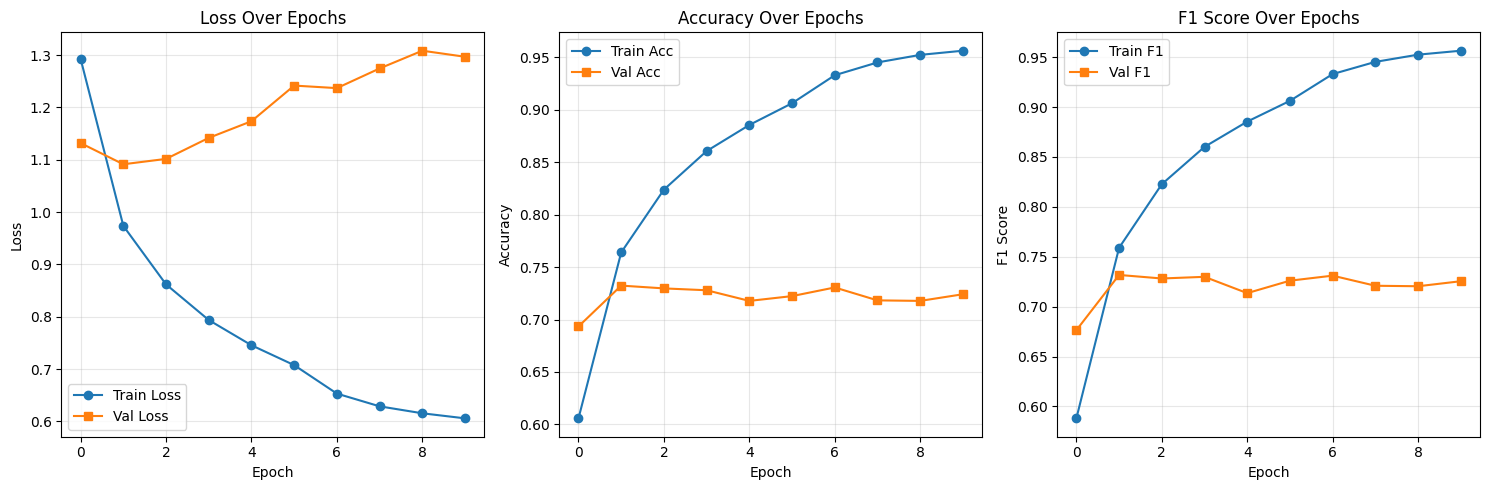


Evaluating xLSTM on Test Set



Testing: 100%|██████████| 247/247 [00:11<00:00, 20.97it/s]


Test Accuracy:  0.7299
Test Precision: 0.7336
Test Recall:    0.7299
Test F1 Score:  0.7313

CLASSIFICATION REPORT
                      precision    recall  f1-score   support

             Anxiety     0.7925    0.7361    0.7633       576
             Bipolar     0.7494    0.7170    0.7328       417
          Depression     0.6740    0.6544    0.6640      2309
              Normal     0.9096    0.8976    0.9036      2432
Personality disorder     0.5405    0.6173    0.5764       162
              Stress     0.5240    0.5619    0.5423       388
            Suicidal     0.5968    0.6368    0.6162      1597

            accuracy                         0.7299      7881
           macro avg     0.6838    0.6887    0.6855      7881
        weighted avg     0.7336    0.7299    0.7313      7881



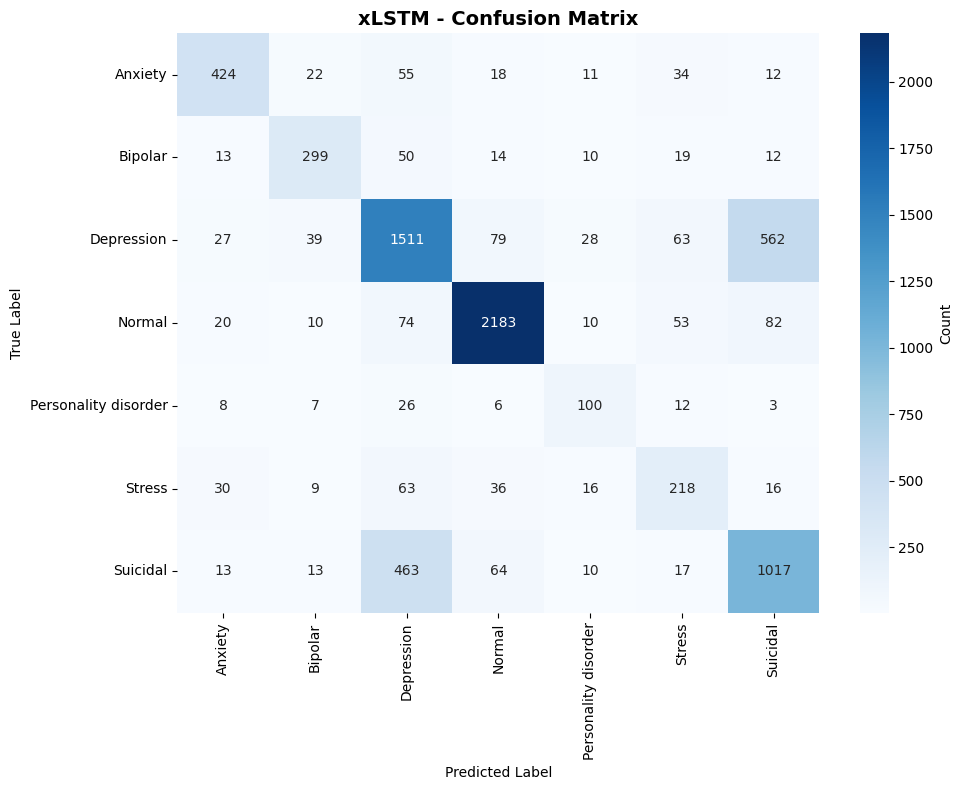


PER-CLASS ACCURACY
Anxiety             :  73.61%
Bipolar             :  71.70%
Depression          :  65.44%
Normal              :  89.76%
Personality disorder:  61.73%
Stress              :  56.19%
Suicidal            :  63.68%

✓ Model saved to xLSTM_best.pth



ALL MODELS TRAINED SUCCESSFULLY!


In [131]:
# ═══════════════════════════════════════════════════════════════
# Cell 5: Train All Models
# ═══════════════════════════════════════════════════════════════

# Dictionary to store results
results2 = {}
trained_models2 = {}

# Models to train
model_configs = {
    # 'RNN': 'rnn',
    # 'LSTM': 'lstm',
    # 'BiLSTM': 'bilstm',
    # 'xBiLSTM': 'xbilstm',
    'xLSTM': 'xlstm',
}

for model_name, model_type in model_configs.items():
    print(f"\n{'#'*70}")
    print(f"# Training {model_name}")
    print(f"{'#'*70}\n")
    
    # Build model
    model = build_model(model_type, config, VOCAB_SIZE, NUM_CLASSES)
    
    # Loss function with label smoothing
    criterion = LabelSmoothingCrossEntropy(smoothing=LABEL_SMOOTHING)
    
    # Optimizer
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )
    
    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='max',
        factor=0.5,
        patience=3,
        # verbose=True,
        min_lr=1e-6
    )
    
    # Trainer
    trainer = Trainer(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        grad_clip=GRAD_CLIP,
        early_stopping_patience=EARLY_STOPPING_PATIENCE,
        model_name=model_name
    )
    
    # Train
    metrics_tracker = trainer.train(num_epochs=config.NUM_EPOCHS)
    
    # Plot training history
    metrics_tracker.plot_history()
    
    # Evaluate on test set
    test_metrics, test_labels, test_preds = trainer.evaluate_test(test_loader, class_names)
    
    # Store results
    results2[model_name] = {
        'metrics_tracker': metrics_tracker,
        'test_metrics': test_metrics,
        'test_labels': test_labels,
        'test_preds': test_preds,
        'best_val_f1': trainer.best_val_f1
    }
    
    trained_models2[model_name] = trainer.model
    
    # Save model checkpoint
    checkpoint_path = f"{model_name}_best.pth"
    torch.save(trainer.best_model_state, checkpoint_path)
    print(f"\n✓ Model saved to {checkpoint_path}")
    
    print(f"\n{'='*70}\n")

print("\n" + "="*70)
print("ALL MODELS TRAINED SUCCESSFULLY!")
print("="*70)



######################################################################
# Training xLSTM
######################################################################


Training xLSTM



Epoch 01/10 | Time: 1150.03s | LR: 0.001000
  Train Loss: 1.2854 | Acc: 0.6197 | F1: 0.6069
  Val   Loss: 1.1049 | Acc: 0.6986 | F1: 0.6791


Epoch 02/10 | Time: 1968.09s | LR: 0.001000
  Train Loss: 1.0366 | Acc: 0.7452 | F1: 0.7409
  Val   Loss: 1.0907 | Acc: 0.7048 | F1: 0.6923


Epoch 03/10 | Time: 1186.36s | LR: 0.001000
  Train Loss: 0.9356 | Acc: 0.7999 | F1: 0.7984
  Val   Loss: 1.0379 | Acc: 0.7250 | F1: 0.7194


Epoch 04/10 | Time: 1187.48s | LR: 0.001000
  Train Loss: 0.8697 | Acc: 0.8376 | F1: 0.8369
  Val   Loss: 1.0759 | Acc: 0.7100 | F1: 0.7007


...

Epoch 06/10 | Time: 1211.68s | LR: 0.001000
  Train Loss: 0.7920 | Acc: 0.8753 | F1: 0.8750
  Val   Loss: 1.0939 | Acc: 0.6963 | F1: 0.6828


Epoch 07/10 | Time: 1197.94s | LR: 0.000500
  Train Loss: 0.7657 | Acc: 0.8894 | F1: 0.8891
  Val   Loss: 1.1028 | Acc: 0.6978 | F1: 0.6865


Epoch 08/10 | Time: 1197.84s | LR: 0.000500
  Train Loss: 0.7112 | Acc: 0.9165 | F1: 0.9165
  Val   Loss: 1.0893 | Acc: 0.7024 | F1: 0.6924


Epoch 09/10 | Time: 1184.19s | LR: 0.000500
  Train Loss: 0.6839 | Acc: 0.9300 | F1: 0.9300
  Val   Loss: 1.0922 | Acc: 0.7058 | F1: 0.6984


Epoch 10/10 | Time: 1210.90s | LR: 0.000500
  Train Loss: 0.6710 | Acc: 0.9362 | F1: 0.9362
  Val   Loss: 1.1238 | Acc: 0.6978 | F1: 0.6867

Training completed in 242.54 minutes
Best Val F1: 0.7194



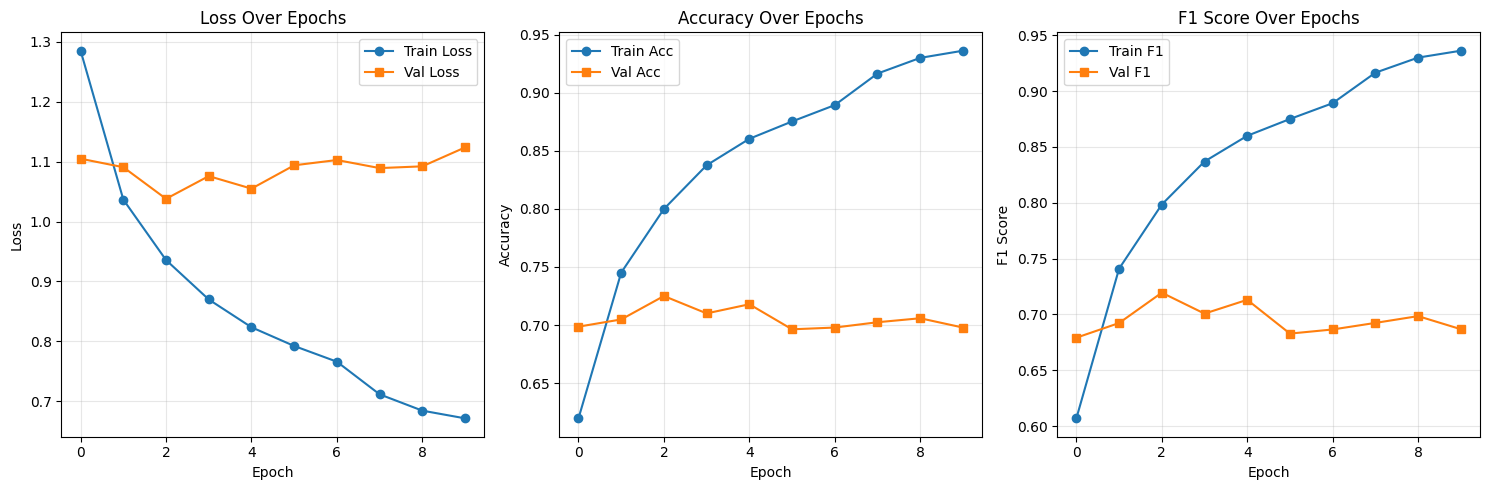


Evaluating xLSTM on Test Set



Testing: 100%|██████████| 247/247 [01:42<00:00,  2.41it/s]


Test Accuracy:  0.7094
Test Precision: 0.7093
Test Recall:    0.7094
Test F1 Score:  0.6981

CLASSIFICATION REPORT
                      precision    recall  f1-score   support

             Anxiety     0.7853    0.6858    0.7322       576
             Bipolar     0.8916    0.5324    0.6667       417
          Depression     0.6338    0.7007    0.6656      2309
              Normal     0.7933    0.9482    0.8638      2432
Personality disorder     0.8525    0.3210    0.4664       162
              Stress     0.6384    0.2912    0.4000       388
            Suicidal     0.6184    0.5542    0.5845      1597

            accuracy                         0.7094      7881
           macro avg     0.7447    0.5762    0.6256      7881
        weighted avg     0.7093    0.7094    0.6981      7881



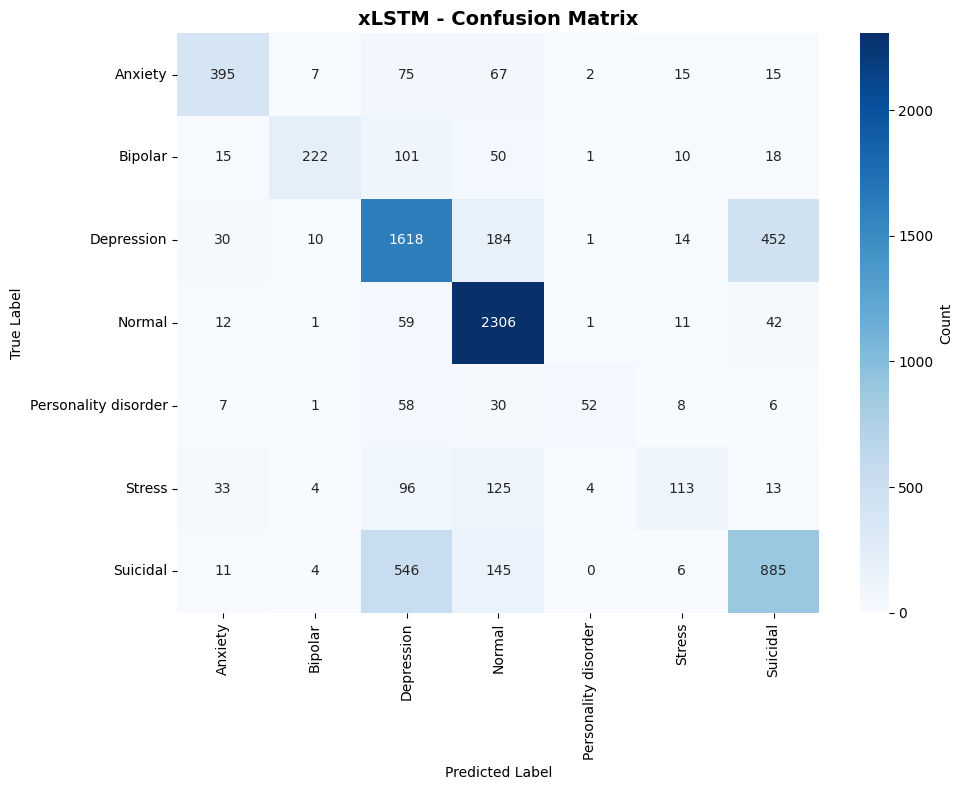


PER-CLASS ACCURACY
Anxiety             :  68.58%
Bipolar             :  53.24%
Depression          :  70.07%
Normal              :  94.82%
Personality disorder:  32.10%
Stress              :  29.12%
Suicidal            :  55.42%

✓ Model saved to xLSTM_best.pth



ALL MODELS TRAINED SUCCESSFULLY!


In [ ]:
# ═══════════════════════════════════════════════════════════════
# Cell 5: Train All Models
# ═══════════════════════════════════════════════════════════════

# Dictionary to store results
results = {}
trained_models = {}

# Models to train
model_configs = {
    # 'RNN': 'rnn',
    # 'LSTM': 'lstm',
    # 'BiLSTM': 'bilstm',
    # 'xBiLSTM': 'xbilstm',
    'xLSTM': 'xlstm',
}

for model_name, model_type in model_configs.items():
    print(f"\n{'#'*70}")
    print(f"# Training {model_name}")
    print(f"{'#'*70}\n")
    
    # Build model
    model = build_model(model_type, config, VOCAB_SIZE, NUM_CLASSES)
    
    # Loss function with label smoothing
    criterion = LabelSmoothingCrossEntropy(smoothing=LABEL_SMOOTHING)
    
    # Optimizer
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )
    
    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='max',
        factor=0.5,
        patience=3,
        # verbose=True,
        min_lr=1e-6
    )
    
    # Trainer
    trainer = Trainer(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        grad_clip=GRAD_CLIP,
        early_stopping_patience=EARLY_STOPPING_PATIENCE,
        model_name=model_name
    )
    
    # Train
    metrics_tracker = trainer.train(num_epochs=config.NUM_EPOCHS)
    
    # Plot training history
    metrics_tracker.plot_history()
    
    # Evaluate on test set
    test_metrics, test_labels, test_preds = trainer.evaluate_test(test_loader, class_names)
    
    # Store results
    results[model_name] = {
        'metrics_tracker': metrics_tracker,
        'test_metrics': test_metrics,
        'test_labels': test_labels,
        'test_preds': test_preds,
        'best_val_f1': trainer.best_val_f1
    }
    
    trained_models[model_name] = trainer.model
    
    # Save model checkpoint
    checkpoint_path = f"{model_name}_best.pth"
    torch.save(trainer.best_model_state, checkpoint_path)
    print(f"\n✓ Model saved to {checkpoint_path}")
    
    print(f"\n{'='*70}\n")

print("\n" + "="*70)
print("ALL MODELS TRAINED SUCCESSFULLY!")
print("="*70)



######################################################################
# Training RNN
######################################################################


Training RNN



Epoch 01/10 | Time: 55.44s | LR: 0.001000
  Train Loss: 1.7649 | Acc: 0.4158 | F1: 0.3790
  Val   Loss: 1.4546 | Acc: 0.5274 | F1: 0.4162


Epoch 02/10 | Time: 54.59s | LR: 0.001000
  Train Loss: 1.4399 | Acc: 0.5178 | F1: 0.4455
  Val   Loss: 1.3745 | Acc: 0.5415 | F1: 0.4826


Epoch 03/10 | Time: 54.98s | LR: 0.001000
  Train Loss: 1.3551 | Acc: 0.5417 | F1: 0.4898
  Val   Loss: 1.4539 | Acc: 0.4845 | F1: 0.4259


Epoch 04/10 | Time: 54.90s | LR: 0.001000
  Train Loss: 1.3235 | Acc: 0.5609 | F1: 0.5147
  Val   Loss: 1.3004 | Acc: 0.5197 | F1: 0.4449


...

Epoch 06/10 | Time: 55.35s | LR: 0.001000
  Train Loss: 1.2637 | Acc: 0.5960 | F1: 0.5609
  Val   Loss: 1.2721 | Acc: 0.5783 | F1: 0.5527


Epoch 07/10 | Time: 54.72s | LR: 0.001000
  Train Loss: 1.2451 | Acc: 0.6050 | F1: 0.5704
  Val   Loss: 1.2397 | Acc: 0.5881 | F1: 0.5357


Epoch 08/10 | Time: 54.86s | LR: 0.001000
  Train Loss: 1.2398 | Acc: 0.6101 | F1: 0.5749
  Val   Loss: 1.3206 | Acc: 0.5693 | F1: 0.4913


Epoch 09/10 | Time: 55.31s | LR: 0.001000
  Train Loss: 1.2270 | Acc: 0.6144 | F1: 0.5807
  Val   Loss: 1.2564 | Acc: 0.5813 | F1: 0.5349


Epoch 10/10 | Time: 54.87s | LR: 0.001000
  Train Loss: 1.2185 | Acc: 0.6225 | F1: 0.5895
  Val   Loss: 1.2209 | Acc: 0.6160 | F1: 0.5787

Training completed in 9.17 minutes
Best Val F1: 0.5787



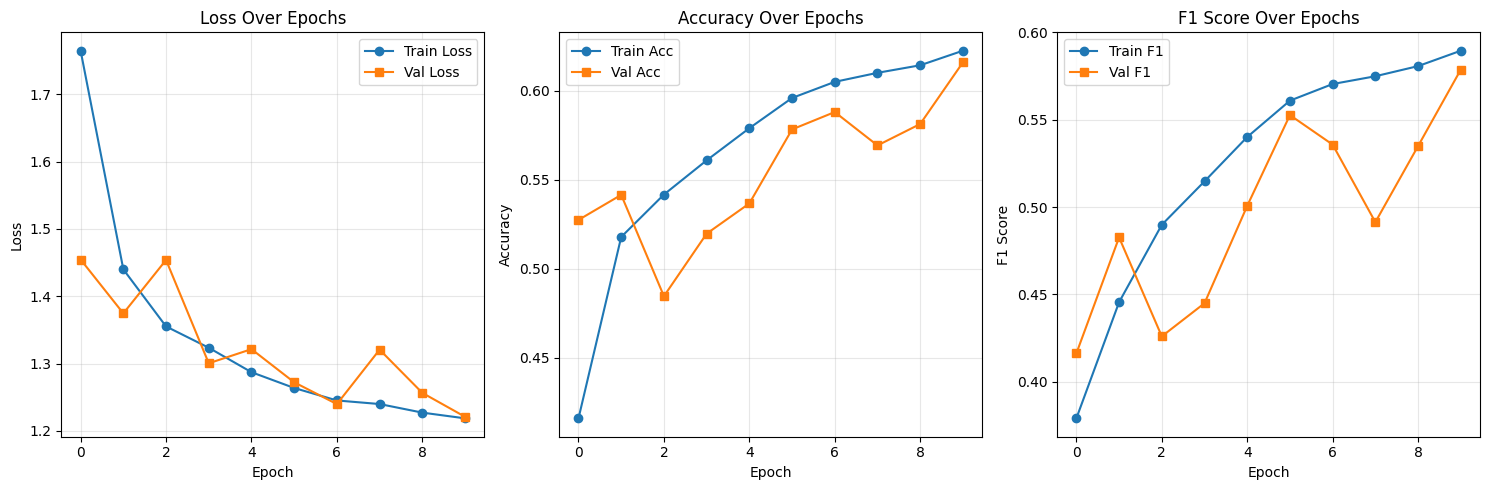


Evaluating RNN on Test Set



Testing: 100%|██████████| 247/247 [00:01<00:00, 149.66it/s]

Test Accuracy:  0.6172
Test Precision: 0.5608
Test Recall:    0.6172
Test F1 Score:  0.5796

CLASSIFICATION REPORT
                      precision    recall  f1-score   support

             Anxiety     0.3384    0.7413    0.4646       576
             Bipolar     0.0000    0.0000    0.0000       417
          Depression     0.6139    0.5041    0.5536      2309
              Normal     0.8013    0.9186    0.8559      2432
Personality disorder     0.0000    0.0000    0.0000       162
              Stress     0.0000    0.0000    0.0000       388
            Suicidal     0.5375    0.6506    0.5887      1597

            accuracy                         0.6172      7881
           macro avg     0.3273    0.4021    0.3518      7881
        weighted avg     0.5608    0.6172    0.5796      7881



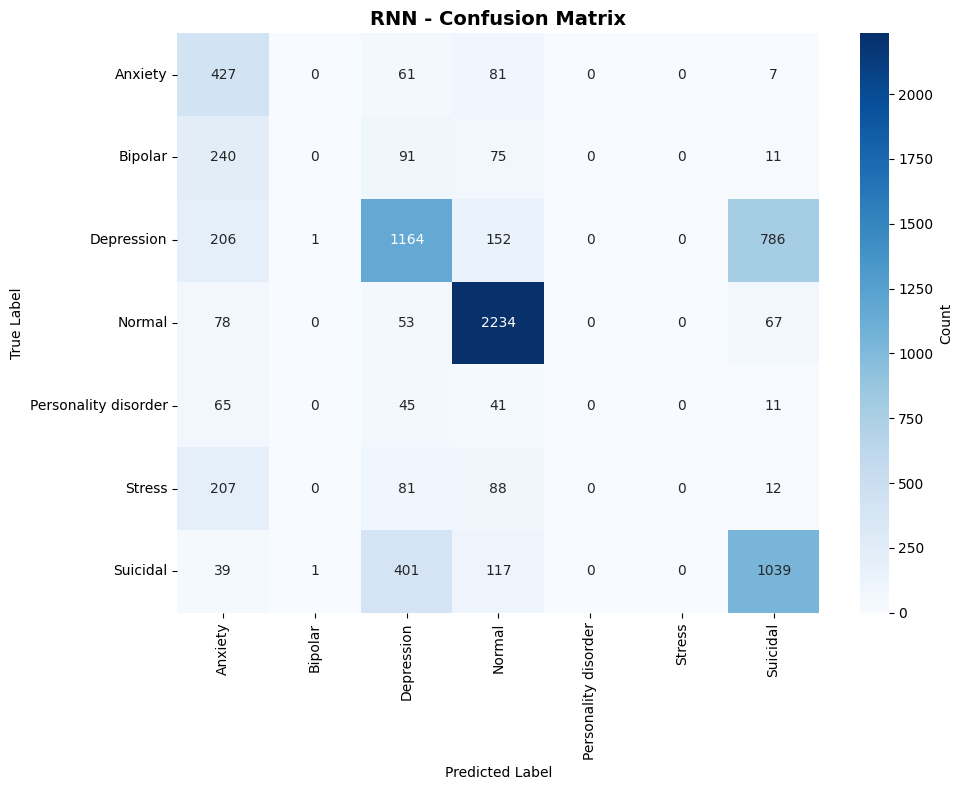


PER-CLASS ACCURACY
Anxiety             :  74.13%
Bipolar             :   0.00%
Depression          :  50.41%
Normal              :  91.86%
Personality disorder:   0.00%
Stress              :   0.00%
Suicidal            :  65.06%

✓ Model saved to RNN_best.pth



######################################################################
# Training LSTM
######################################################################


Training LSTM



Epoch 01/10 | Time: 154.71s | LR: 0.001000
  Train Loss: 1.5531 | Acc: 0.5066 | F1: 0.4820
  Val   Loss: 1.2572 | Acc: 0.6152 | F1: 0.5891


Epoch 02/10 | Time: 158.96s | LR: 0.001000
  Train Loss: 1.2170 | Acc: 0.6335 | F1: 0.6058
  Val   Loss: 1.1290 | Acc: 0.6712 | F1: 0.6447


Epoch 03/10 | Time: 159.26s | LR: 0.001000
  Train Loss: 1.1263 | Acc: 0.6903 | F1: 0.6774
  Val   Loss: 1.0556 | Acc: 0.7217 | F1: 0.7082


Epoch 04/10 | Time: 157.18s | LR: 0.001000
  Train Loss: 1.0567 | Acc: 0.7305 | F1: 0.7207
  Val   Loss: 1.0886 | Acc: 0.7226 | F1: 0.7134


...

Epoch 06/10 | Time: 158.11s | LR: 0.001000
  Train Loss: 0.9898 | Acc: 0.7660 | F1: 0.7603
  Val   Loss: 1.0385 | Acc: 0.7322 | F1: 0.7297


Epoch 07/10 | Time: 157.00s | LR: 0.001000
  Train Loss: 0.9644 | Acc: 0.7757 | F1: 0.7723
  Val   Loss: 1.0247 | Acc: 0.7463 | F1: 0.7432


Epoch 08/10 | Time: 153.63s | LR: 0.001000
  Train Loss: 0.9423 | Acc: 0.7906 | F1: 0.7880
  Val   Loss: 1.0509 | Acc: 0.7499 | F1: 0.7438


Epoch 09/10 | Time: 155.30s | LR: 0.001000
  Train Loss: 0.9300 | Acc: 0.7994 | F1: 0.7973
  Val   Loss: 1.0535 | Acc: 0.7278 | F1: 0.7225


Epoch 10/10 | Time: 155.34s | LR: 0.001000
  Train Loss: 0.9115 | Acc: 0.8064 | F1: 0.8047
  Val   Loss: 1.0453 | Acc: 0.7381 | F1: 0.7340

Training completed in 26.14 minutes
Best Val F1: 0.7438



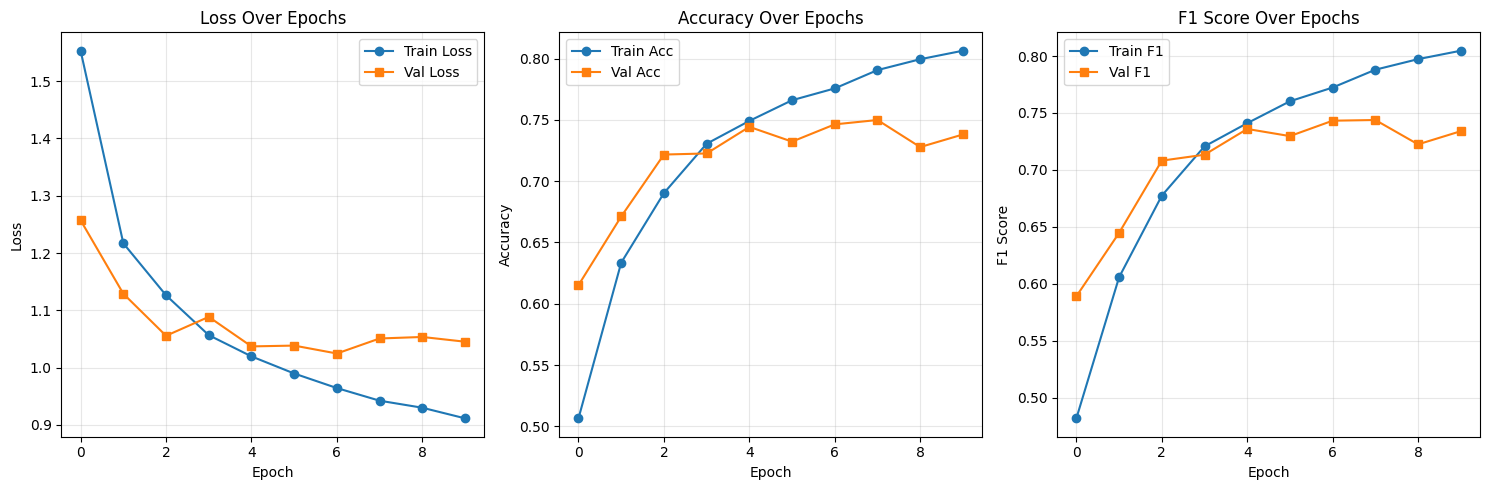


Evaluating LSTM on Test Set



Testing: 100%|██████████| 247/247 [00:04<00:00, 52.05it/s]


Test Accuracy:  0.7410
Test Precision: 0.7519
Test Recall:    0.7410
Test F1 Score:  0.7373

CLASSIFICATION REPORT
                      precision    recall  f1-score   support

             Anxiety     0.7526    0.7604    0.7565       576
             Bipolar     0.8554    0.6811    0.7583       417
          Depression     0.7402    0.5873    0.6549      2309
              Normal     0.8877    0.9260    0.9064      2432
Personality disorder     0.8049    0.4074    0.5410       162
              Stress     0.5652    0.4021    0.4699       388
            Suicidal     0.5750    0.8065    0.6714      1597

            accuracy                         0.7410      7881
           macro avg     0.7401    0.6530    0.6798      7881
        weighted avg     0.7519    0.7410    0.7373      7881



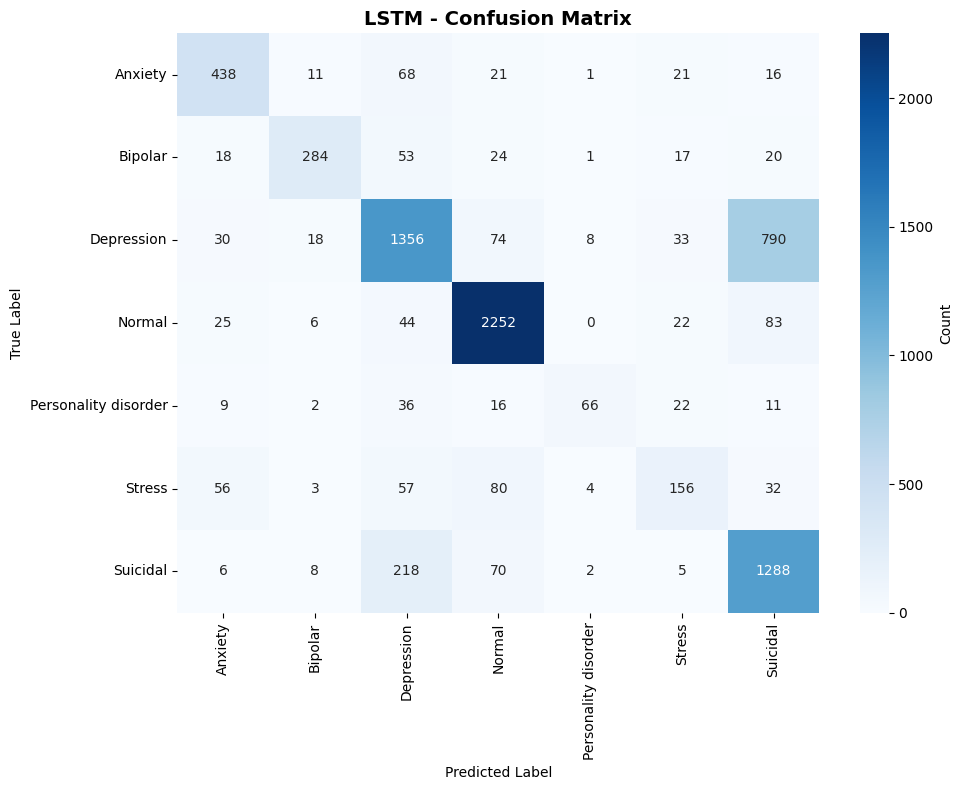


PER-CLASS ACCURACY
Anxiety             :  76.04%
Bipolar             :  68.11%
Depression          :  58.73%
Normal              :  92.60%
Personality disorder:  40.74%
Stress              :  40.21%
Suicidal            :  80.65%

✓ Model saved to LSTM_best.pth



######################################################################
# Training BiLSTM
######################################################################


Training BiLSTM



Epoch 01/10 | Time: 292.71s | LR: 0.001000
  Train Loss: 1.5115 | Acc: 0.5377 | F1: 0.5226
  Val   Loss: 1.2000 | Acc: 0.6400 | F1: 0.6317


Epoch 02/10 | Time: 297.26s | LR: 0.001000
  Train Loss: 1.1548 | Acc: 0.6736 | F1: 0.6602
  Val   Loss: 1.0759 | Acc: 0.7168 | F1: 0.7056


Epoch 03/10 | Time: 299.52s | LR: 0.001000
  Train Loss: 1.0718 | Acc: 0.7184 | F1: 0.7087
  Val   Loss: 1.0745 | Acc: 0.7133 | F1: 0.7080


Epoch 04/10 | Time: 300.03s | LR: 0.001000
  Train Loss: 1.0188 | Acc: 0.7452 | F1: 0.7408
  Val   Loss: 1.0458 | Acc: 0.7381 | F1: 0.7382


...

Epoch 06/10 | Time: 301.17s | LR: 0.001000
  Train Loss: 0.9457 | Acc: 0.7859 | F1: 0.7837
  Val   Loss: 1.0176 | Acc: 0.7543 | F1: 0.7539


Epoch 07/10 | Time: 311.26s | LR: 0.001000
  Train Loss: 0.9182 | Acc: 0.7979 | F1: 0.7959
  Val   Loss: 1.0376 | Acc: 0.7511 | F1: 0.7499


Epoch 08/10 | Time: 319.58s | LR: 0.001000
  Train Loss: 0.8993 | Acc: 0.8094 | F1: 0.8079
  Val   Loss: 1.0446 | Acc: 0.7538 | F1: 0.7549


Epoch 09/10 | Time: 316.47s | LR: 0.001000
  Train Loss: 0.8811 | Acc: 0.8194 | F1: 0.8182
  Val   Loss: 1.0185 | Acc: 0.7527 | F1: 0.7510


Epoch 10/10 | Time: 323.79s | LR: 0.001000
  Train Loss: 0.8677 | Acc: 0.8253 | F1: 0.8244
  Val   Loss: 1.0423 | Acc: 0.7589 | F1: 0.7597

Training completed in 51.12 minutes
Best Val F1: 0.7597



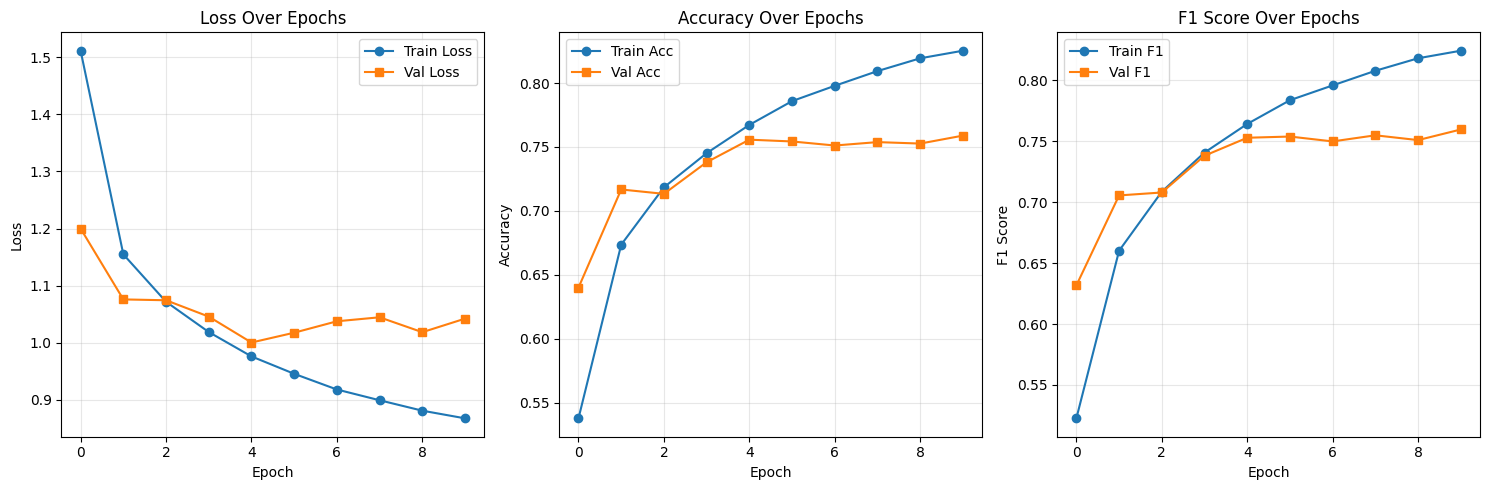


Evaluating BiLSTM on Test Set



Testing: 100%|██████████| 247/247 [00:10<00:00, 23.54it/s]


Test Accuracy:  0.7543
Test Precision: 0.7637
Test Recall:    0.7543
Test F1 Score:  0.7554

CLASSIFICATION REPORT
                      precision    recall  f1-score   support

             Anxiety     0.7559    0.7743    0.7650       576
             Bipolar     0.8311    0.7314    0.7781       417
          Depression     0.7345    0.6600    0.6953      2309
              Normal     0.9168    0.9153    0.9160      2432
Personality disorder     0.8378    0.3827    0.5254       162
              Stress     0.4767    0.6340    0.5442       388
            Suicidal     0.6204    0.7113    0.6628      1597

            accuracy                         0.7543      7881
           macro avg     0.7390    0.6870    0.6981      7881
        weighted avg     0.7637    0.7543    0.7554      7881



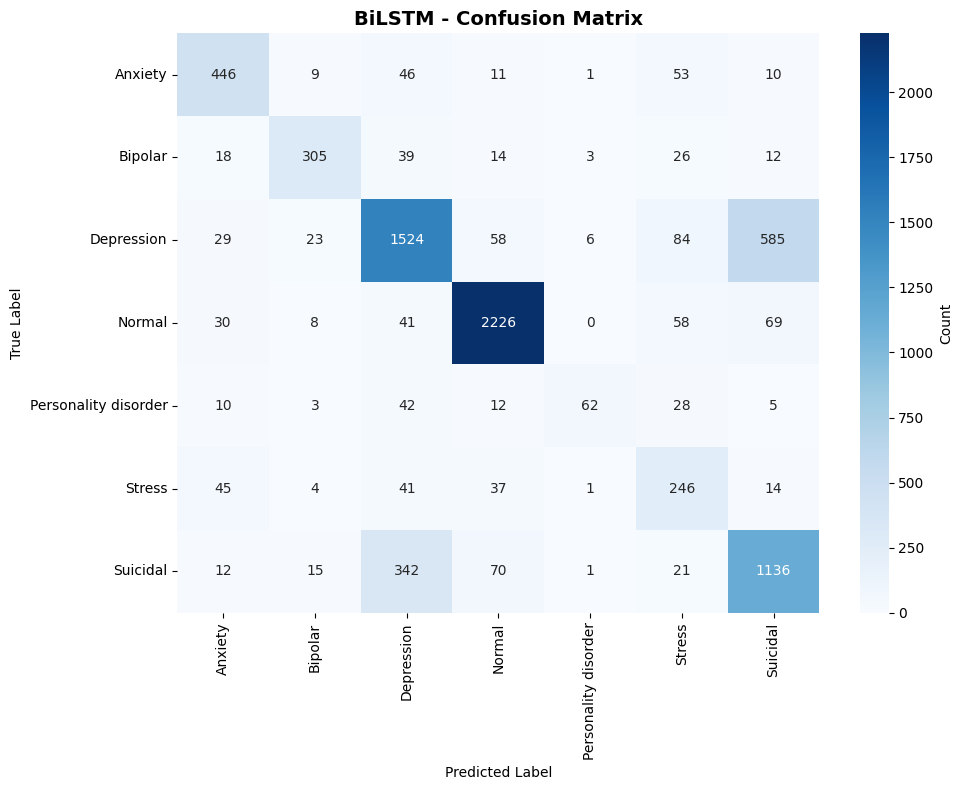


PER-CLASS ACCURACY
Anxiety             :  77.43%
Bipolar             :  73.14%
Depression          :  66.00%
Normal              :  91.53%
Personality disorder:  38.27%
Stress              :  63.40%
Suicidal            :  71.13%

✓ Model saved to BiLSTM_best.pth



ALL MODELS TRAINED SUCCESSFULLY!


In [120]:
# ═══════════════════════════════════════════════════════════════
# Cell 5: Train All Models
# ═══════════════════════════════════════════════════════════════

# Dictionary to store results
results = {}
trained_models = {}

# Models to train
model_configs = {
    'RNN': 'rnn',
    'LSTM': 'lstm',
    'BiLSTM': 'bilstm',
    # 'xBiLSTM': 'xbilstm',
}

for model_name, model_type in model_configs.items():
    print(f"\n{'#'*70}")
    print(f"# Training {model_name}")
    print(f"{'#'*70}\n")
    
    # Build model
    model = build_model(model_type, config, VOCAB_SIZE, NUM_CLASSES)
    
    # Loss function with label smoothing
    criterion = LabelSmoothingCrossEntropy(smoothing=LABEL_SMOOTHING)
    
    # Optimizer
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )
    
    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='max',
        factor=0.5,
        patience=3,
        # verbose=True,
        min_lr=1e-6
    )
    
    # Trainer
    trainer = Trainer(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        grad_clip=GRAD_CLIP,
        early_stopping_patience=EARLY_STOPPING_PATIENCE,
        model_name=model_name
    )
    
    # Train
    metrics_tracker = trainer.train(num_epochs=config.NUM_EPOCHS)
    
    # Plot training history
    metrics_tracker.plot_history()
    
    # Evaluate on test set
    test_metrics, test_labels, test_preds = trainer.evaluate_test(test_loader, class_names)
    
    # Store results
    results[model_name] = {
        'metrics_tracker': metrics_tracker,
        'test_metrics': test_metrics,
        'test_labels': test_labels,
        'test_preds': test_preds,
        'best_val_f1': trainer.best_val_f1
    }
    
    trained_models[model_name] = trainer.model
    
    # Save model checkpoint
    checkpoint_path = f"{model_name}_best.pth"
    torch.save(trainer.best_model_state, checkpoint_path)
    print(f"\n✓ Model saved to {checkpoint_path}")
    
    print(f"\n{'='*70}\n")

print("\n" + "="*70)
print("ALL MODELS TRAINED SUCCESSFULLY!")
print("="*70)


In [132]:
# اضافه کردن results2 به results
results.update(results2)
trained_models.update(trained_models2)

print(f"✓ Updated results. Total models: {len(results)}")
print(f"Models: {list(results.keys())}")


✓ Updated results. Total models: 4
Models: ['RNN', 'LSTM', 'BiLSTM', 'xLSTM']



MODEL COMPARISON - SORTED BY TEST F1 SCORE

 Model  Best Epoch   Val F1  Test Accuracy  Test Precision  Test Recall  Test F1
BiLSTM          10 0.759692       0.754346        0.763739     0.754346 0.755363
  LSTM           8 0.743837       0.741023        0.751938     0.741023 0.737303
 xLSTM           2 0.731797       0.729857        0.733572     0.729857 0.731349
   RNN          10 0.578677       0.617181        0.560789     0.617181 0.579584




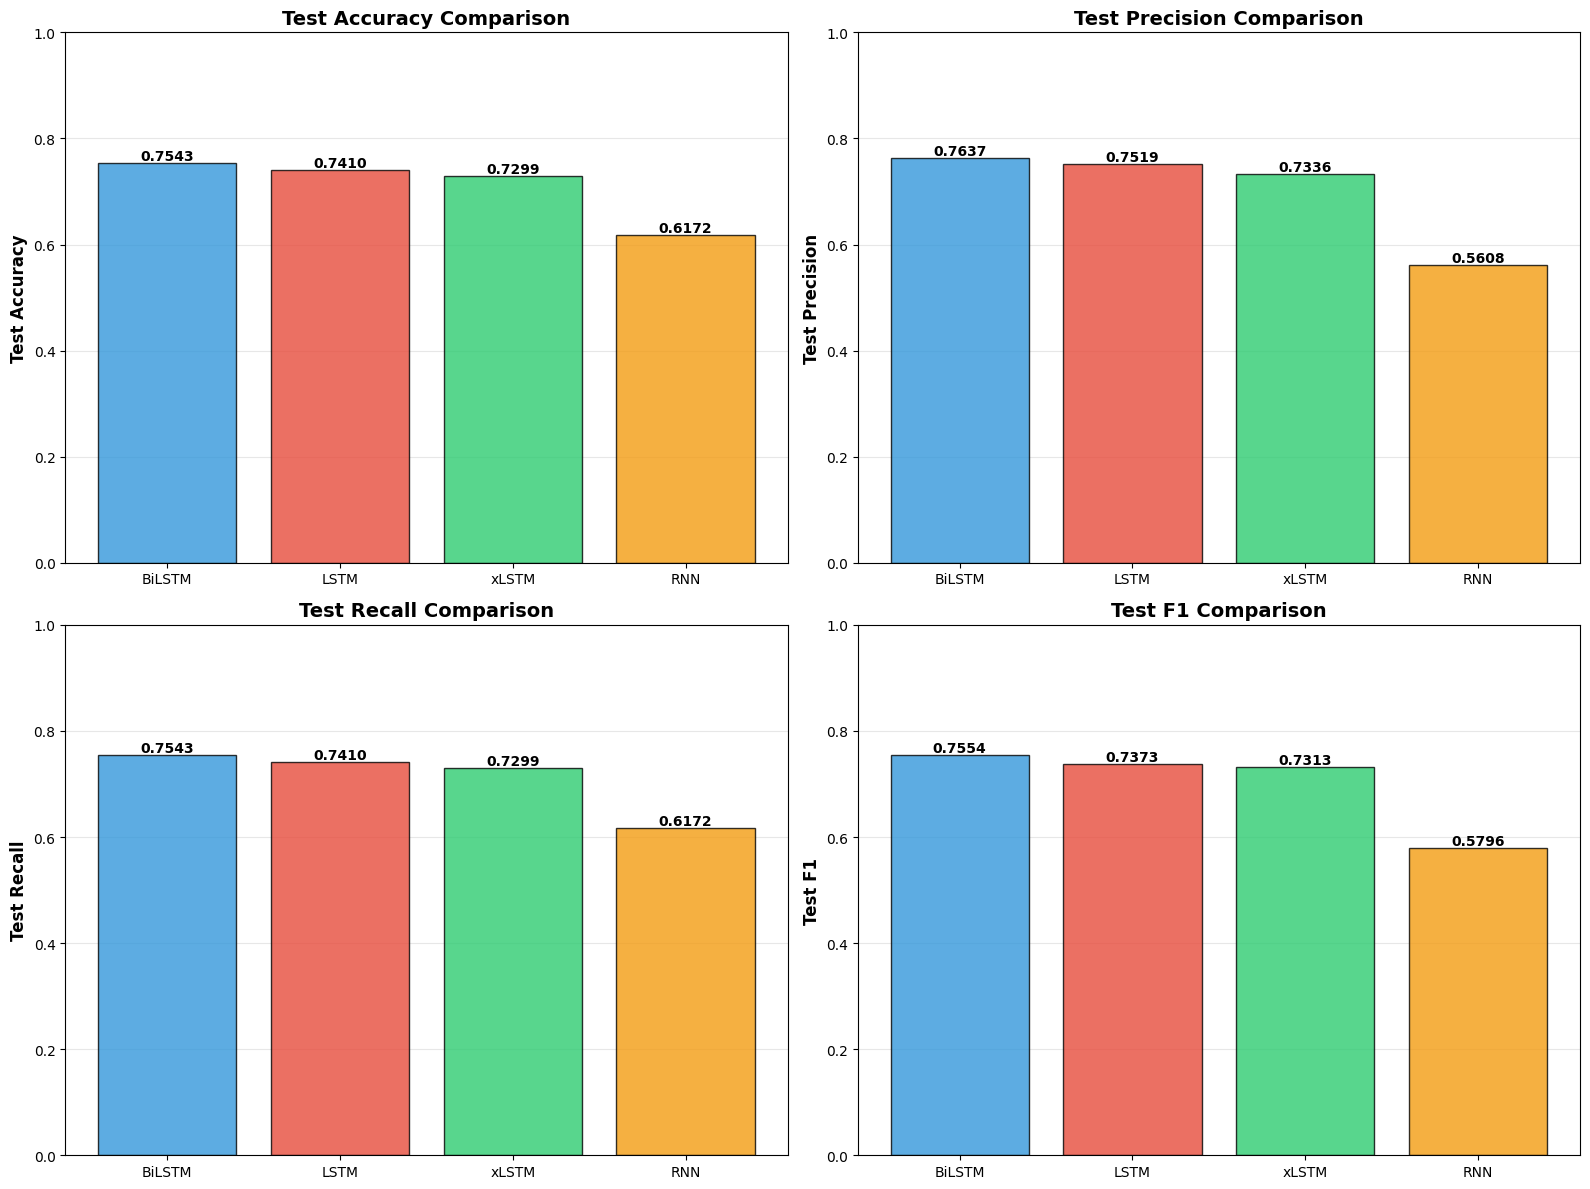


🏆 BEST MODEL: BiLSTM with Test F1 = 0.7554


In [133]:
# ═══════════════════════════════════════════════════════════════
# Cell 6: Model Comparison
# ═══════════════════════════════════════════════════════════════

# Create comparison dataframe
comparison_data = []

for model_name, result in results.items():
    test_metrics = result['test_metrics']
    best_val_f1 = result['best_val_f1']
    
    # Get best epoch info
    metrics_tracker = result['metrics_tracker']
    best_epoch, _ = metrics_tracker.get_best_epoch('val_f1', 'max')
    
    comparison_data.append({
        'Model': model_name,
        'Best Epoch': best_epoch,
        'Val F1': best_val_f1,
        'Test Accuracy': test_metrics['accuracy'],
        'Test Precision': test_metrics['precision'],
        'Test Recall': test_metrics['recall'],
        'Test F1': test_metrics['f1']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Test F1', ascending=False)

print(f"\n{'='*80}")
print("MODEL COMPARISON - SORTED BY TEST F1 SCORE")
print(f"{'='*80}\n")
print(comparison_df.to_string(index=False))
print(f"\n{'='*80}\n")

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics_to_plot = ['Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    
    bars = ax.bar(
        comparison_df['Model'],
        comparison_df[metric],
        color=colors,
        alpha=0.8,
        edgecolor='black'
    )
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2.,
            height,
            f'{height:.4f}',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )
    
    ax.set_ylabel(metric, fontsize=12, fontweight='bold')
    ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    ax.set_ylim([0, 1.0])
    ax.grid(axis='y', alpha=0.3)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# Best model
best_model_name = comparison_df.iloc[0]['Model']
best_f1 = comparison_df.iloc[0]['Test F1']

print(f"\n🏆 BEST MODEL: {best_model_name} with Test F1 = {best_f1:.4f}")


In [134]:
# ═══════════════════════════════════════════════════════════════
# Cell: Compare Models
# ═══════════════════════════════════════════════════════════════

comparison_data = []

for model_name, result in results.items():
    test_metrics = result['test_metrics']
    
    # Check if model was trained (has best_val_f1) or just loaded
    if 'best_val_f1' in result:
        best_val_f1 = result['best_val_f1']
        metrics_tracker = result['metrics_tracker']
        best_epoch = metrics_tracker.get_best_epoch()
    else:
        # Model was loaded from checkpoint, no training history
        best_val_f1 = None
        best_epoch = None
    
    comparison_data.append({
        'Model': model_name,
        'Test Accuracy': test_metrics['accuracy'],
        'Test Precision': test_metrics['precision'],
        'Test Recall': test_metrics['recall'],
        'Test F1': test_metrics['f1'],
        'Best Val F1': best_val_f1 if best_val_f1 else test_metrics['f1'],
        'Best Epoch': best_epoch if best_epoch else 'N/A'
    })

# Create comparison DataFrame
comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Test F1', ascending=False)

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)



MODEL COMPARISON
 Model  Test Accuracy  Test Precision  Test Recall  Test F1  Best Val F1               Best Epoch
BiLSTM       0.754346        0.763739     0.754346 0.755363     0.759692 (10, 0.7596920070838277)
  LSTM       0.741023        0.751938     0.741023 0.737303     0.743837  (8, 0.7438365802835937)
 xLSTM       0.729857        0.733572     0.729857 0.731349     0.731797  (2, 0.7317969444697482)
   RNN       0.617181        0.560789     0.617181 0.579584     0.578677 (10, 0.5786771824628064)



OVERFITTING ANALYSIS

 Model  Train Acc  Val Acc  Acc Gap  Train F1   Val F1   F1 Gap
   RNN   0.622549 0.615990 0.006559  0.589522 0.578677 0.010845
BiLSTM   0.825307 0.758883 0.066423  0.824359 0.759692 0.064667
  LSTM   0.806380 0.738071 0.068309  0.804657 0.734030 0.070627
 xLSTM   0.956463 0.724112 0.232351  0.956472 0.725505 0.230968

Note: Lower gap indicates better generalization



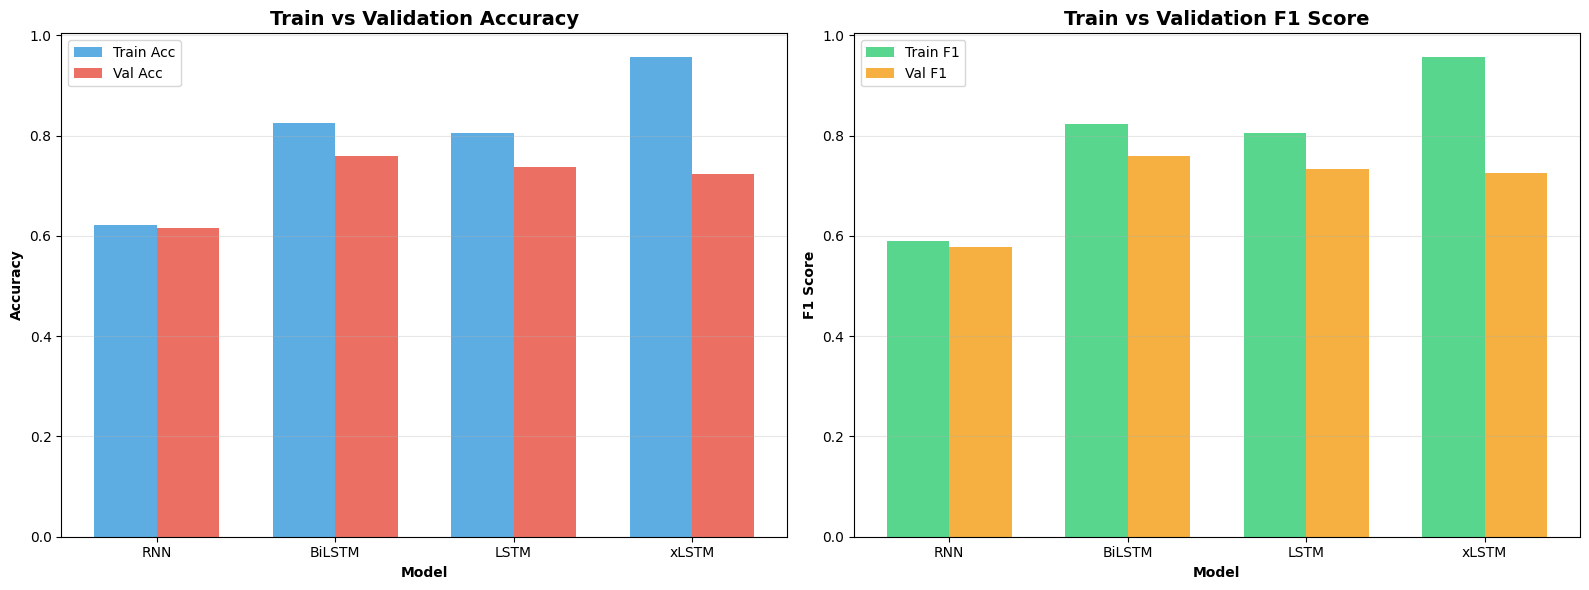

In [135]:
# ═══════════════════════════════════════════════════════════════
# Cell 7: Overfitting Analysis
# ═══════════════════════════════════════════════════════════════

print(f"\n{'='*80}")
print("OVERFITTING ANALYSIS")
print(f"{'='*80}\n")

overfitting_data = []

for model_name, result in results.items():
    metrics_tracker = result['metrics_tracker']
    
    # Get final train and val metrics
    final_train_acc = metrics_tracker.history['train_acc'][-1]
    final_val_acc = metrics_tracker.history['val_acc'][-1]
    final_train_f1 = metrics_tracker.history['train_f1'][-1]
    final_val_f1 = metrics_tracker.history['val_f1'][-1]
    
    # Calculate gaps
    acc_gap = final_train_acc - final_val_acc
    f1_gap = final_train_f1 - final_val_f1
    
    overfitting_data.append({
        'Model': model_name,
        'Train Acc': final_train_acc,
        'Val Acc': final_val_acc,
        'Acc Gap': acc_gap,
        'Train F1': final_train_f1,
        'Val F1': final_val_f1,
        'F1 Gap': f1_gap
    })

overfitting_df = pd.DataFrame(overfitting_data)
overfitting_df = overfitting_df.sort_values('F1 Gap')

print(overfitting_df.to_string(index=False))
print(f"\n{'='*80}")
print("Note: Lower gap indicates better generalization")
print(f"{'='*80}\n")

# Visualize overfitting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy comparison
x = np.arange(len(overfitting_df))
width = 0.35

axes[0].bar(x - width/2, overfitting_df['Train Acc'], width, 
            label='Train Acc', alpha=0.8, color='#3498db')
axes[0].bar(x + width/2, overfitting_df['Val Acc'], width, 
            label='Val Acc', alpha=0.8, color='#e74c3c')
axes[0].set_xlabel('Model', fontweight='bold')
axes[0].set_ylabel('Accuracy', fontweight='bold')
axes[0].set_title('Train vs Validation Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(overfitting_df['Model'])
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# F1 comparison
axes[1].bar(x - width/2, overfitting_df['Train F1'], width, 
            label='Train F1', alpha=0.8, color='#2ecc71')
axes[1].bar(x + width/2, overfitting_df['Val F1'], width, 
            label='Val F1', alpha=0.8, color='#f39c12')
axes[1].set_xlabel('Model', fontweight='bold')
axes[1].set_ylabel('F1 Score', fontweight='bold')
axes[1].set_title('Train vs Validation F1 Score', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(overfitting_df['Model'])
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


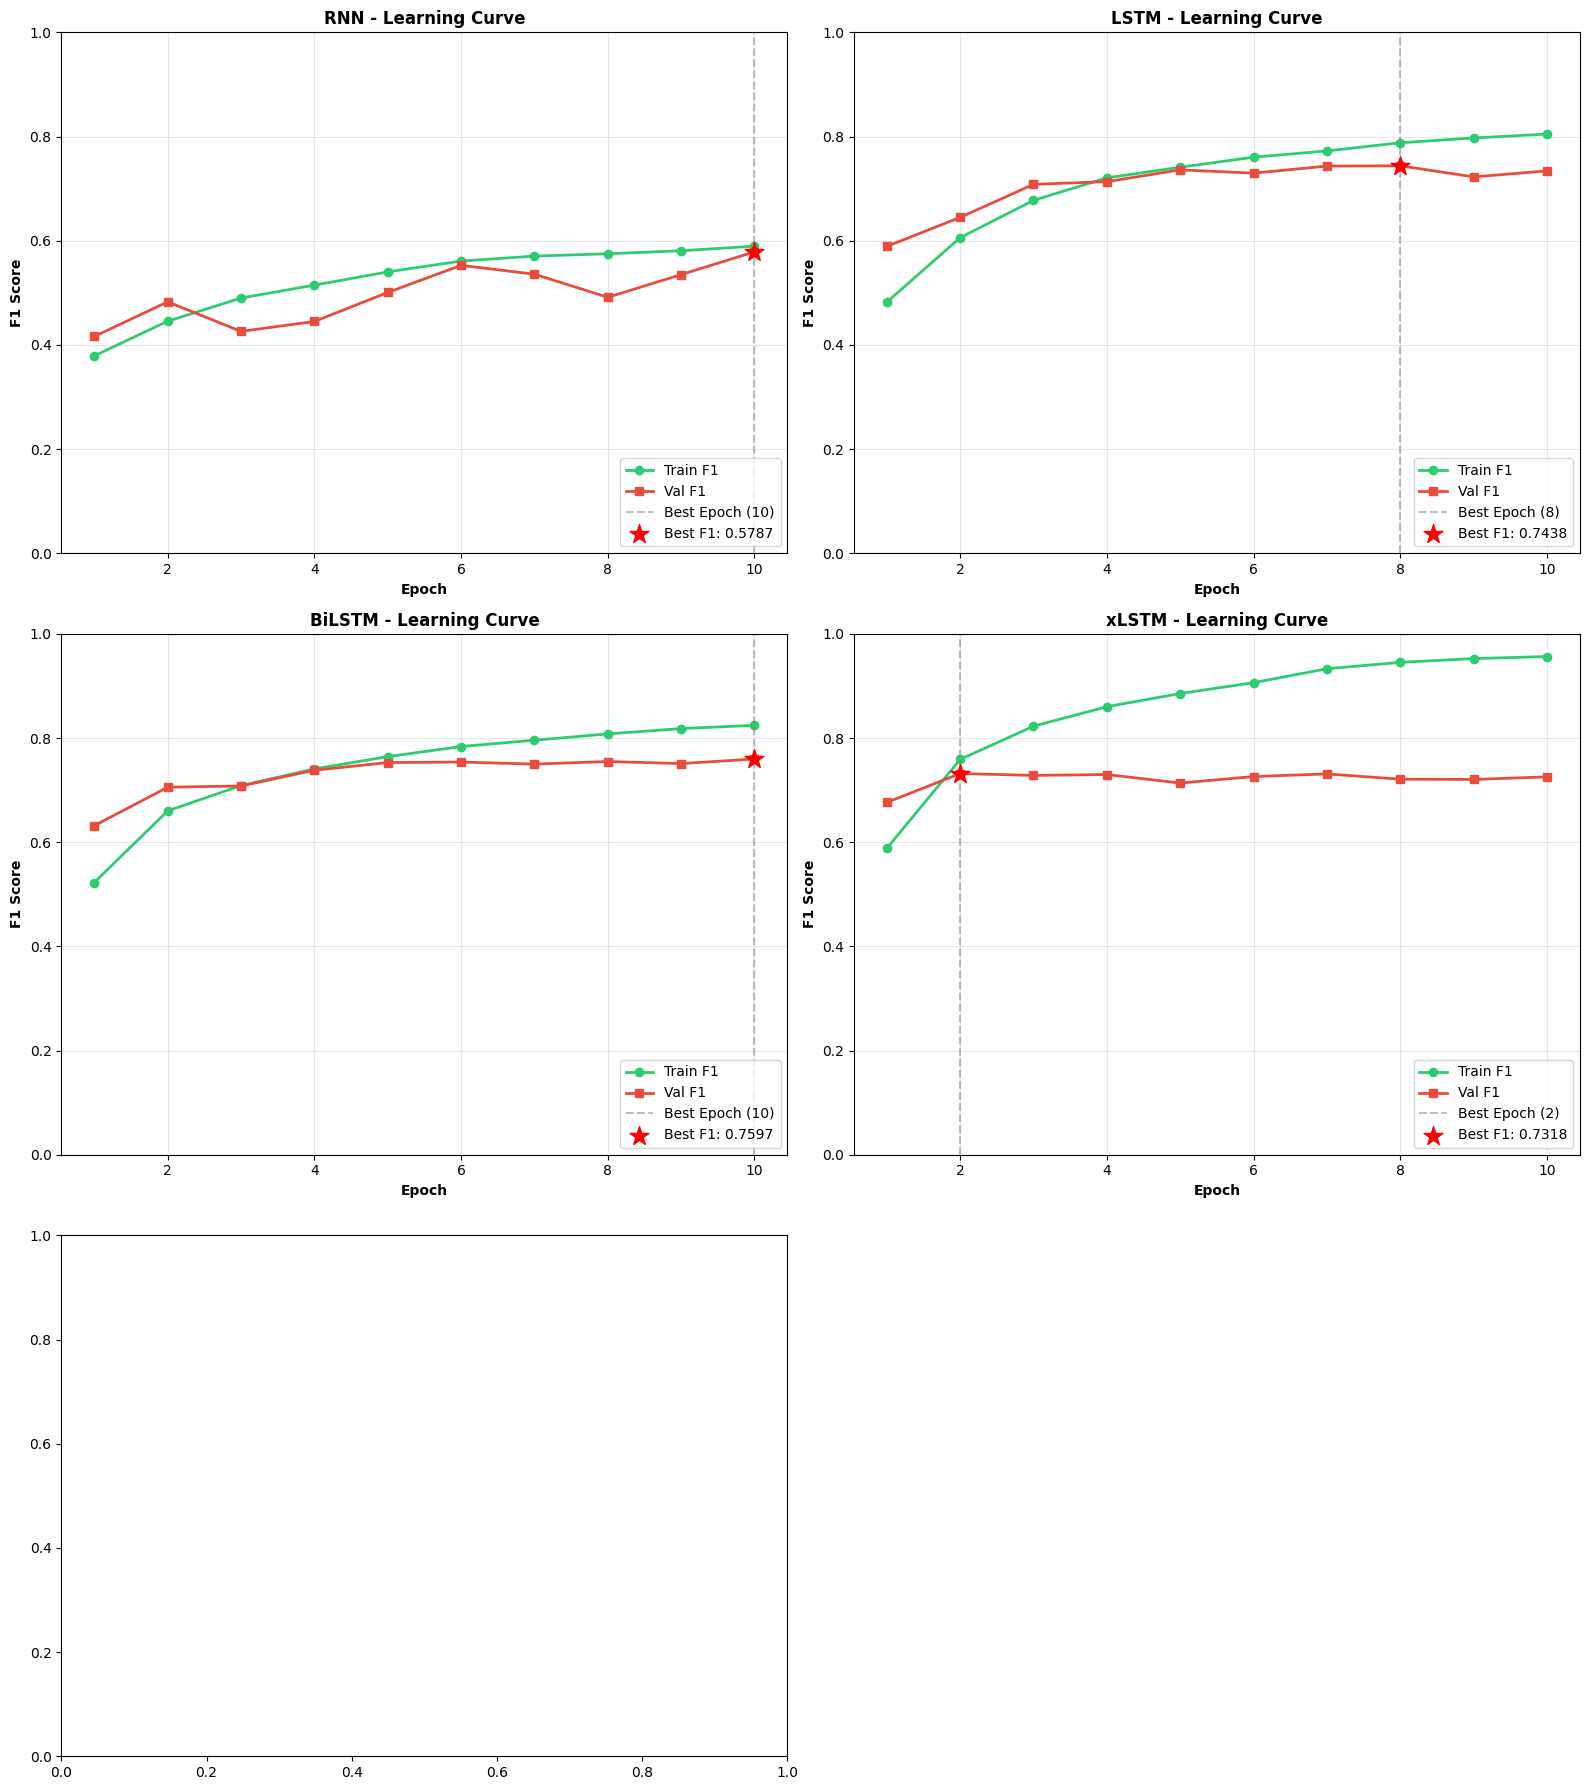

In [136]:
# ═══════════════════════════════════════════════════════════════
# Cell 8: Learning Curves for All Models
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for idx, (model_name, result) in enumerate(results.items()):
    if idx >= len(axes):
        break
    
    metrics_tracker = result['metrics_tracker']
    history = metrics_tracker.history
    
    ax = axes[idx]
    
    # Plot train and val F1
    epochs = range(1, len(history['train_f1']) + 1)
    ax.plot(epochs, history['train_f1'], 'o-', label='Train F1', 
            color='#2ecc71', linewidth=2, markersize=6)
    ax.plot(epochs, history['val_f1'], 's-', label='Val F1', 
            color='#e74c3c', linewidth=2, markersize=6)
    
    # Mark best epoch
    best_epoch, best_f1 = metrics_tracker.get_best_epoch('val_f1', 'max')
    ax.axvline(best_epoch, color='gray', linestyle='--', alpha=0.5, 
               label=f'Best Epoch ({best_epoch})')
    ax.scatter([best_epoch], [best_f1], color='red', s=200, 
               marker='*', zorder=5, label=f'Best F1: {best_f1:.4f}')
    
    ax.set_xlabel('Epoch', fontweight='bold')
    ax.set_ylabel('F1 Score', fontweight='bold')
    ax.set_title(f'{model_name} - Learning Curve', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)
    ax.set_ylim([0, 1.0])

# Remove extra subplot if odd number of models
if len(results) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()


In [137]:
# ═══════════════════════════════════════════════════════════════
# Cell 9: Save Results to CSV
# ═══════════════════════════════════════════════════════════════

# Save comparison results
comparison_df.to_csv('model_comparison_results.csv', index=False)
print("✓ Comparison results saved to 'model_comparison_results.csv'")

# Save overfitting analysis
overfitting_df.to_csv('overfitting_analysis.csv', index=False)
print("✓ Overfitting analysis saved to 'overfitting_analysis.csv'")

# Save training history for each model
for model_name, result in results.items():
    
    metrics_tracker = result['metrics_tracker']
    history_df = pd.DataFrame(metrics_tracker.history)
    
    history_path = f"{model_name}_training_history.csv"
    history_df.to_csv(history_path, index=False)
    
    print(f"✓ {model_name} training history saved to {history_path}")

print("\nAll experiment results saved successfully.")


✓ Comparison results saved to 'model_comparison_results.csv'
✓ Overfitting analysis saved to 'overfitting_analysis.csv'
✓ RNN training history saved to RNN_training_history.csv
✓ LSTM training history saved to LSTM_training_history.csv
✓ BiLSTM training history saved to BiLSTM_training_history.csv
✓ xLSTM training history saved to xLSTM_training_history.csv

All experiment results saved successfully.
